# Projet d'Expansion Internationale : Analyse et Recommandations

*Auteur : Abdulkadir GUVEN*

*Date : Juillet 2025*

## 0. Initialisation : Importation des Bibliothèques et Utilitaires

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
import missingno as msno
from contextlib import contextmanager
import time
import os

#%matplotlib inline
    
# Custom eda functions
import academy_toolkit.data_utils as du

In [2]:
@contextmanager
def track_dataframe_changes(df_name, name="DataFrame"):
    original_shape = globals()[df_name].shape
    print(f"{name} avant: {original_shape}")
    start_time = time.time()  
    yield
    elapsed_time = time.time() - start_time  
    new_shape = globals()[df_name].shape
    print(f"{name} après: {new_shape}")
    
    rows_diff = original_shape[0] - new_shape[0]
    cols_diff = original_shape[1] - new_shape[1]
    
    if rows_diff > 0:
        print(f"  ✂️  Lignes supprimées: {rows_diff}")
    elif rows_diff < 0:
        print(f"  ➕ Lignes ajoutées: {abs(rows_diff)}")
    
    if cols_diff > 0:
        print(f"  🗑️  Colonnes supprimées: {cols_diff}")
    elif cols_diff < 0:
        print(f"  📊 Colonnes ajoutées: {abs(cols_diff)}")
    
    if rows_diff == 0 and cols_diff == 0:
        print(f"  🔄 Aucun changement de dimension")
    
    print(f"  ⏱️  Temps: {elapsed_time:.4f}s")  
    print("-" * 40) 

## 1. Contexte et Objectifs de la Mission

### Contexte

Dans le cadre de notre projet d'expansion internationale, notre entreprise, **Academy**, a initié une démarche pour identifier les marchés les plus prometteurs. Cette analyse se concentre sur notre public cible – les étudiants de niveau lycée et université.

Pour ce faire, nous avons mené une première exploration des données sur l'éducation de la Banque Mondiale afin d'évaluer leur potentiel stratégique et d'en tirer des recommandations concrètes.

### Objectifs de la Mission

Confiée par notre manager, Mark, cette mission vise à :

1.  **Identifier** les pays à fort potentiel de clients pour nos services, en analysant la situation actuelle et les dynamiques d'évolution.

2.  **Développer** une méthodologie quantitative et réutilisable pour évaluer et classer ce potentiel sur la base d'indicateurs clés (démographiques, économiques, et technologiques).

3.  **Valider** si les données de la Banque Mondiale peuvent, à l'avenir, constituer une source fiable pour guider les décisions stratégiques de notre entreprise.

## 2. Analyse Exploratoire et Nettoyage des Données Sources

### 2.1. 💽Chargement des fichiers Sources

In [3]:
if 'COLAB_GPU' in os.environ or 'COLAB_TPU_ADDR' in os.environ:
    print ("Current environement is Google Colab")
    from google.colab import drive
    drive.mount('/content/drive')
    data_path = "/content/drive/MyDrive/Data/"
else:
    data_path = "../data"

country_df = pd.read_csv(f'{data_path}/EdStatsCountry.csv', delimiter=",")
country_series_df = pd.read_csv(f'{data_path}/EdStatsCountry-Series.csv', delimiter=",")
data_df = pd.read_csv(f'{data_path}/EdStatsData.csv', delimiter=",")
footnote_df = pd.read_csv(f'{data_path}/EdStatsFootNote.csv', delimiter=",")
series_df = pd.read_csv(f'{data_path}/EdStatsSeries.csv', delimiter=",")

# Save initial shapes of dataframes
initial_shapes  = {}
initial_shapes["country"] = country_df.shape
initial_shapes["country_series"] = country_series_df.shape
initial_shapes["data"] = data_df.shape
initial_shapes["footnote"] = footnote_df.shape
initial_shapes["series"] = series_df.shape

print("Fichiers chargés avec succès !")

Fichiers chargés avec succès !


### 2.2. 🔷 Informations Initiales sur les Datasets

 | Fichier source | Dataframe | Taille |
| --- | --- | --- |
| EdStatsCountry | country_df  | (241, 32) |
| EdStatsCountry-Series | country_series_df  | (613, 4) |
| EdStatsData | data_df  | (886930, 70) |
| EdStatsFootNote | footnote_df  | (643638, 5) |
| EdStatsSeries | series_df  |  (3665, 21) |

#### ☝️Ce que represente chaque observation de chacun des datasets
- **EdStatsCountry:** Chaque observation represente un pays
- **EdStatsCountry-Series:** Chaque ligne indique qu'une série de données spécifique est disponible pour un pay donné, avec une description.
- **EdStatsData :** La dataframe principale.Chaque ligne contient la valeur numérique ou textuelle d'un indicateur spécifique pour un pays et pendant une année définie.
- **EdStatsFootNote:** Chaque observation est une annotation qui fournit des informations complémentaires ou des avertissements sur une données spécifiques dans EdStatsData
- **EdStatsSeries:** Chaque ligne est une définition détaillée d'un indicateur statistique unique.Elle explique précisément ce que mesure l'indicateur, sa méthodologie, sa source etc.Un métadonnée pour les indicateurs.


### 2.3. ✨ Analyse de [EdStatsCountry]

#### 👀 Vue d'ensemble du dataset

In [4]:
display(Markdown(f"<center><strong> EdStatsCountry.csv {country_df.shape} </strong></center>"))
display(country_df.head(3))

<center><strong> EdStatsCountry.csv (241, 32) </strong></center>

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000,NaN
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,...,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005,NaN


#### 📊 Analyse visuel avec la bibliothéque MissingNo

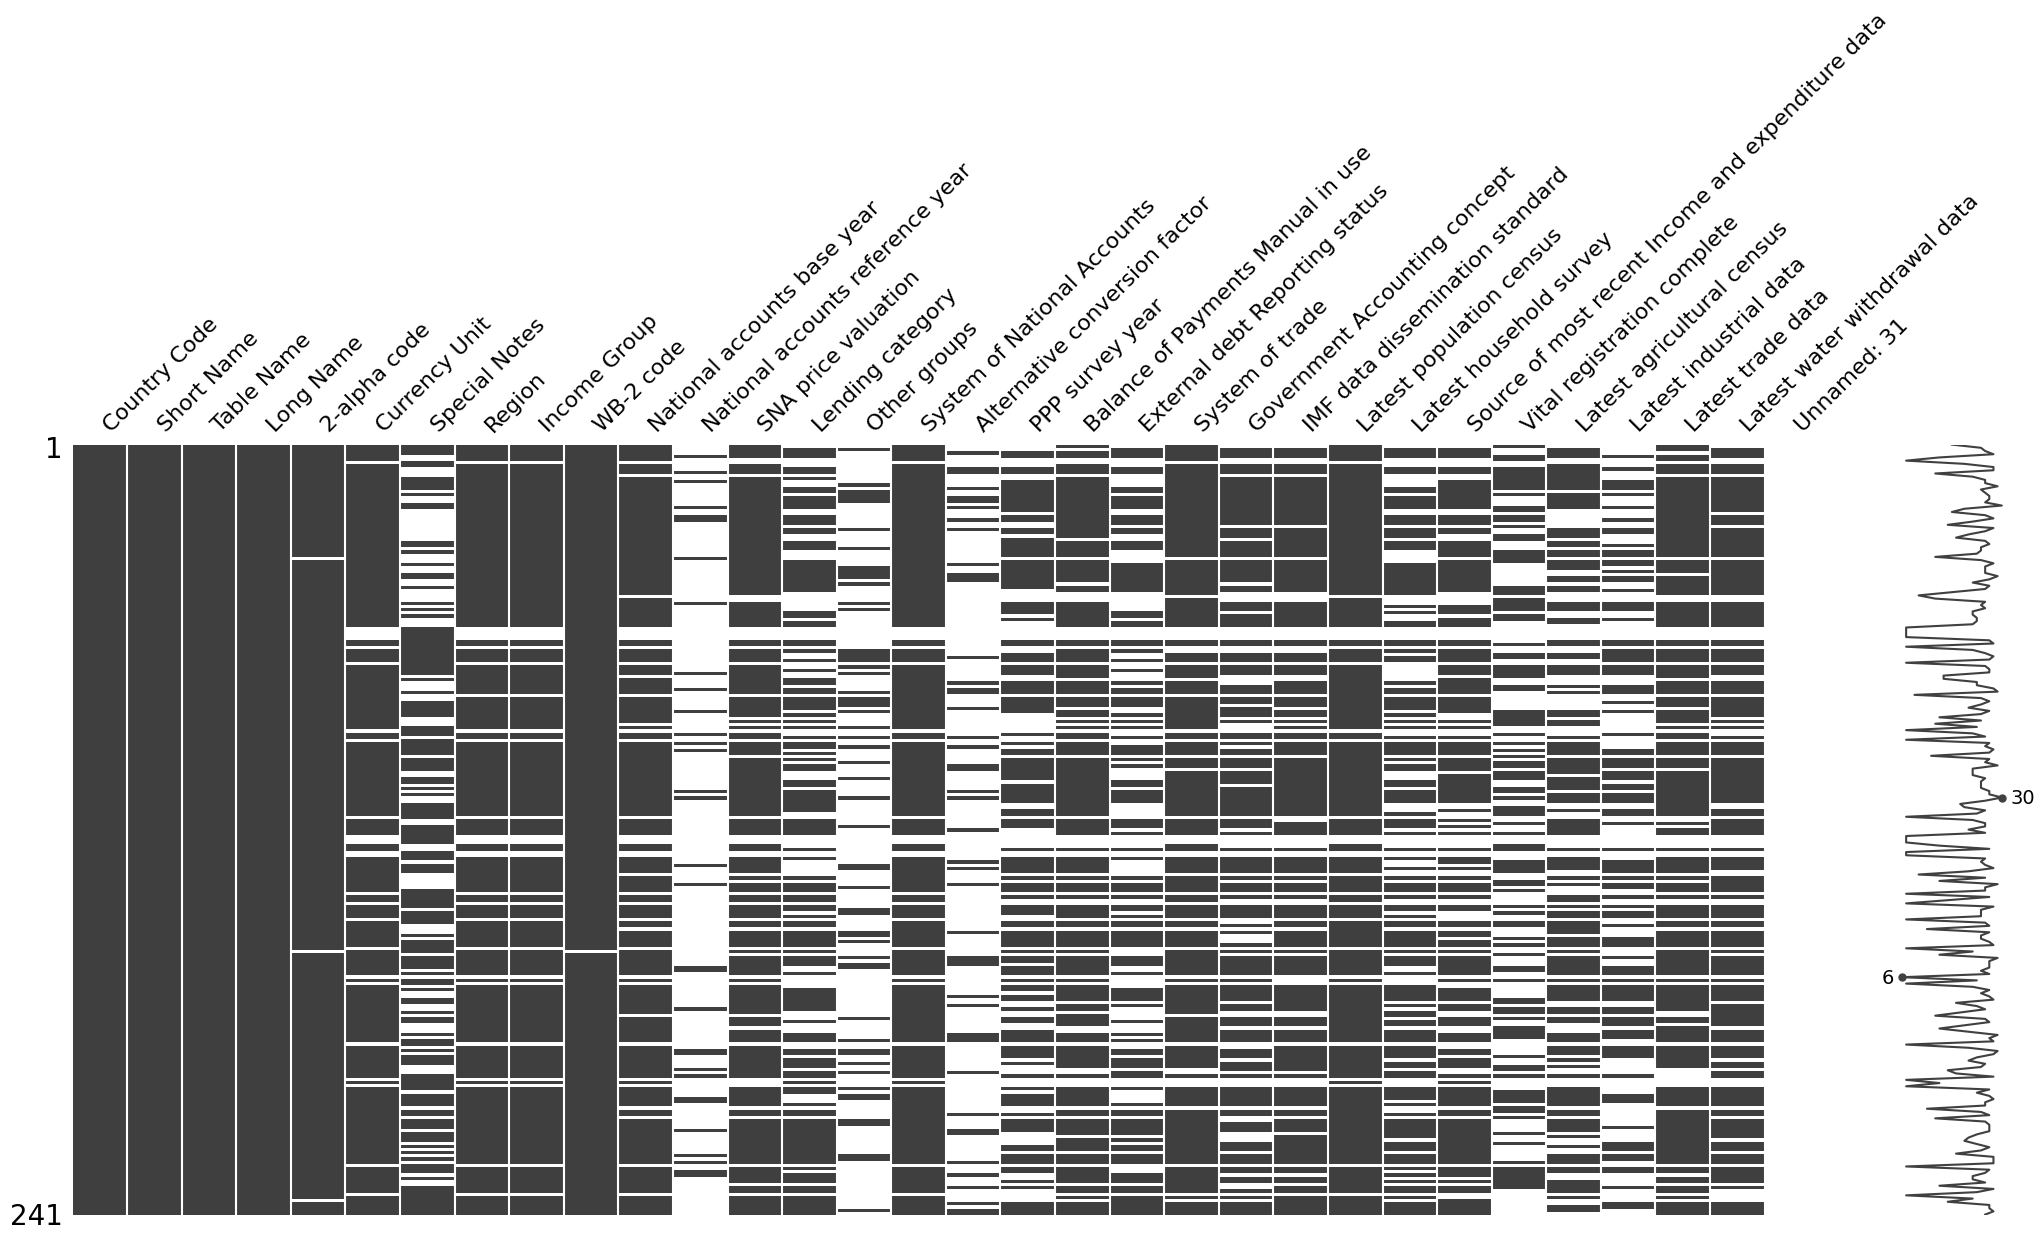

In [5]:
msno.matrix(country_df)
plt.show()

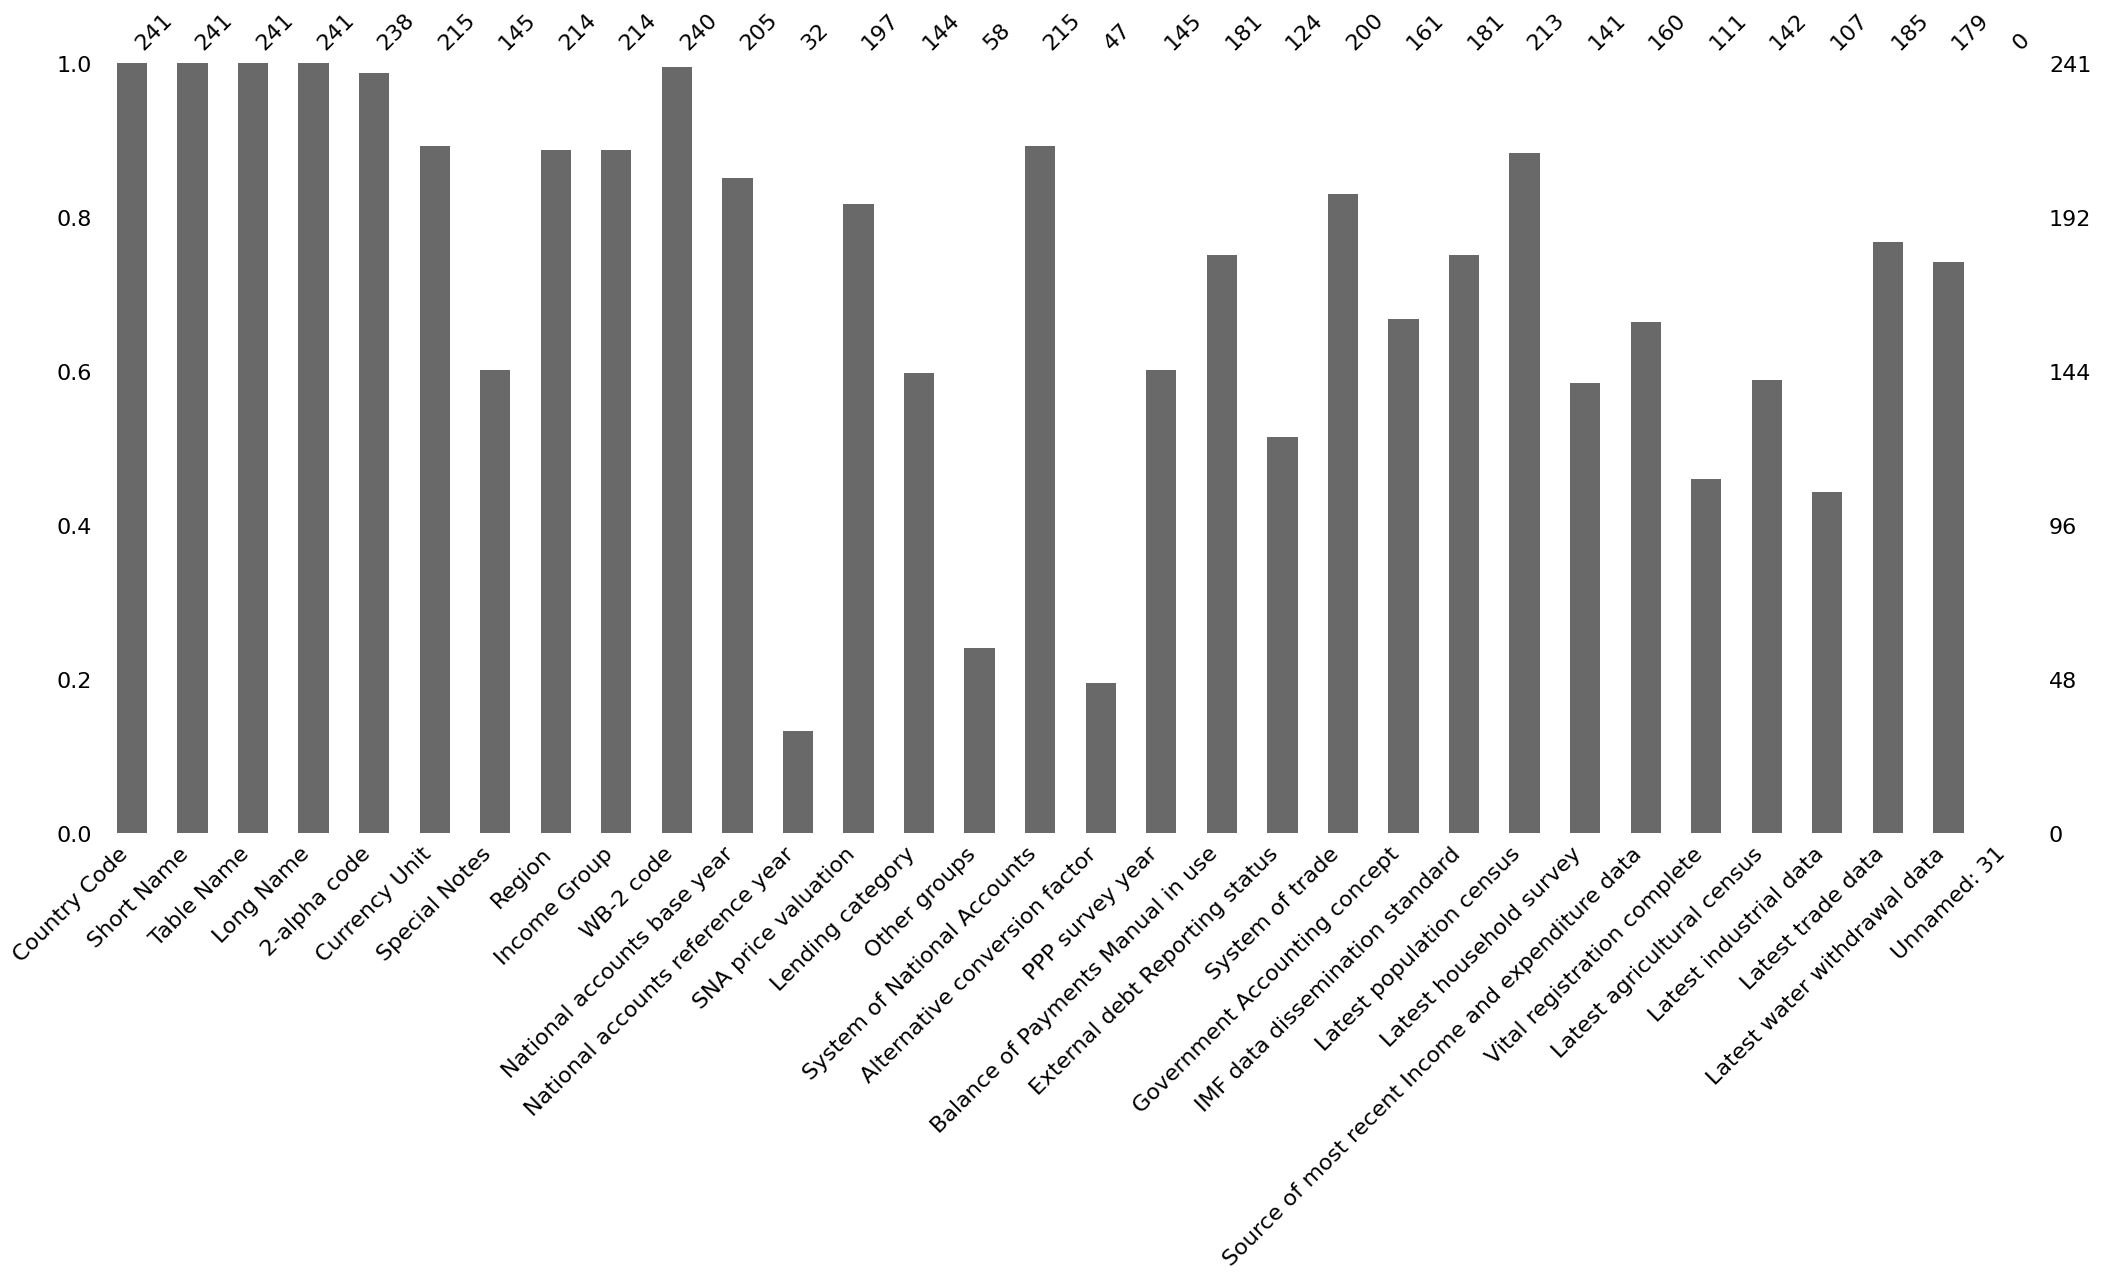

In [6]:
msno.bar(country_df)
plt.show()

**Observations :**
- Les colonnes ayant plus de 50% de valeurs manquantes
  - National accounts reference year
  - Other groups
  - Alternative conversion factor
  - Vital registration complete
  - Latest industrial data
  - Unnamed: 31  

#### 🧹 Nettoyage des colonnes inutiles

In [7]:
# La colonne Unnamed: 31 ne contient aucune information.
country_df = country_df.drop(columns=['Unnamed: 31'])
display(f"Taille avant et après la suppression des colonnes : {initial_shapes['country']} / {country_df.shape}")

'Taille avant et après la suppression des colonnes : (241, 32) / (241, 31)'

#### 🕵️ Analyse détaillée des colonnes

In [8]:
# Affiche les colonnes catégoriques
country_categorical_cols = country_df.select_dtypes(include=['object']).columns
display(country_categorical_cols, len(country_categorical_cols))

Index(['Country Code', 'Short Name', 'Table Name', 'Long Name', '2-alpha code',
       'Currency Unit', 'Special Notes', 'Region', 'Income Group', 'WB-2 code',
       'National accounts base year', 'SNA price valuation',
       'Lending category', 'Other groups', 'System of National Accounts',
       'Alternative conversion factor', 'PPP survey year',
       'Balance of Payments Manual in use', 'External debt Reporting status',
       'System of trade', 'Government Accounting concept',
       'IMF data dissemination standard', 'Latest population census',
       'Latest household survey',
       'Source of most recent Income and expenditure data',
       'Vital registration complete', 'Latest agricultural census',
       'Latest water withdrawal data'],
      dtype='object')

28

In [9]:
du.get_enhanced_info(country_df[country_categorical_cols], verbose=True)

Analyzing 241 rows across 28 columns
Found 24 columns with missing values


,Column,Non-Null,Fill Rate (%),Unique Count,Dtype
0,Country Code,241,100.00,241,object
1,Short Name,241,100.00,241,object
2,Table Name,241,100.00,241,object
3,Long Name,241,100.00,241,object
9,WB-2 code,240,99.59,240,object
4,2-alpha code,238,98.76,238,object
5,Currency Unit,215,89.21,152,object
14,System of National Accounts,215,89.21,3,object
8,Income Group,214,88.80,5,object
7,Region,214,88.80,7,object


**Observations :**

  Les Colonnes
  - Country Code
  - Short Name
  - Table Name
  - Long Name

ne présentent ni valeurs manquantes ni doublons.

In [10]:
# Affiche les colonnes quantitatives
country_numeric_cols = country_df.select_dtypes(include=['number']).columns
display(country_numeric_cols, len(country_numeric_cols))

Index(['National accounts reference year', 'Latest industrial data',
       'Latest trade data'],
      dtype='object')

3

In [11]:
country_df[country_numeric_cols].describe()

,National accounts reference year,Latest industrial data,Latest trade data
count,32.00000,107.000000,185.000000
mean,2001.53125,2008.102804,2010.994595
std,5.24856,2.616834,2.569675
min,1987.00000,2000.000000,1995.000000
25%,1996.75000,2007.500000,2011.000000
50%,2002.00000,2009.000000,2012.000000
75%,2005.00000,2010.000000,2012.000000
max,2012.00000,2010.000000,2012.000000


#### 🔎 Recherche de doublons et valeurs manquantes

In [12]:
# Recherche de doublons pûrs
country_df.duplicated(keep=False).sum()

np.int64(0)

#### 🔢Nombre d'occurrences pour les colonnes catégorielles

In [13]:
for col in country_categorical_cols:
    display(Markdown("---"))
    display(country_df[col].value_counts(dropna=False))

---

Country Code
ABW    1
AFG    1
AGO    1
ALB    1
AND    1
      ..
XKX    1
YEM    1
ZAF    1
ZMB    1
ZWE    1
Name: count, Length: 241, dtype: int64

---

Short Name
Aruba           1
Afghanistan     1
Angola          1
Albania         1
Andorra         1
               ..
Kosovo          1
Yemen           1
South Africa    1
Zambia          1
Zimbabwe        1
Name: count, Length: 241, dtype: int64

---

...

Vital registration complete
NaN                                                 130
Yes                                                 110
Yes. Vital registration for Guernsey and Jersey.      1
Name: count, dtype: int64

---

Latest agricultural census
NaN                                     99
2010                                    36
2007                                    16
2013                                    13
2012                                    10
2011                                     9
2014                                     7
2008                                     5
2009                                     5
2013/ 2014                               4
2010. Population and Housing Census.     3
2015                                     3
2013/14                                  2
2011/12                                  2
2012/13                                  2
2011. Population and Housing Census.     2
2008/ 2009                               2
2011/2012                                2
2011/ 2012                               2
2006                                     1
2013/15                                  1
2009/2010                                1
2010/11                    

---

Latest water withdrawal data
NaN                            62
2000                           40
2005                           40
2007                           18
2002                           16
2009                           12
2006                           10
2001                           10
2008                            6
2003                            6
2004                            6
2010                            4
1999                            2
1993                            2
1994                            1
1986                            1
1997                            1
1979                            1
2005. Includes South Sudan.     1
1975                            1
1995                            1
Name: count, dtype: int64

#### ✅ Résumé de l'analyse initiale de EdStatsCountry

Au cours de cette première phase d'analyse exploratoire du DataFrame `country_df` (`EdStatsCountry.csv`), les opérations suivantes ont été réalisées :

- Le DataFrame a été chargé et ses dimensions initiales ont été notées.
- Une visualisation des valeurs manquantes (MissingNo) a été effectuée pour identifier les colonnes avec une proportion élevée de données manquantes.
- La colonne 'Unnamed: 31', qui était totalement vide, a été supprimée.
- Les types de données (catégoriques et numériques) ont été identifiés et analysés.
- Le nombre d'occurrences pour chaque valeur unique des colonnes catégoriques a été calculé et affiché.
- Une vérification des doublons (purs et basée sur la colonne clé 'Country Code') a confirmé l'absence de doublons dans ce DataFrame.

In [14]:
print(f"Shape initiale : {initial_shapes['country']}")
print(f"Shape finale : {country_df.shape}")

Shape initiale : (241, 32)
Shape finale : (241, 31)


### 2.4. ✨ Analyse de [EdStatsCountry-Series]

#### 👀 Vue d'ensemble du dataset

In [15]:
display(Markdown(f"<center><strong> EdStatsCountry-Series.csv {country_series_df.shape} </strong></center>"))
display(country_series_df.head(3))

<center><strong> EdStatsCountry-Series.csv (613, 4) </strong></center>

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...,NaN


#### 📊 Analyse visuel avec la bibliothéque MissingNo

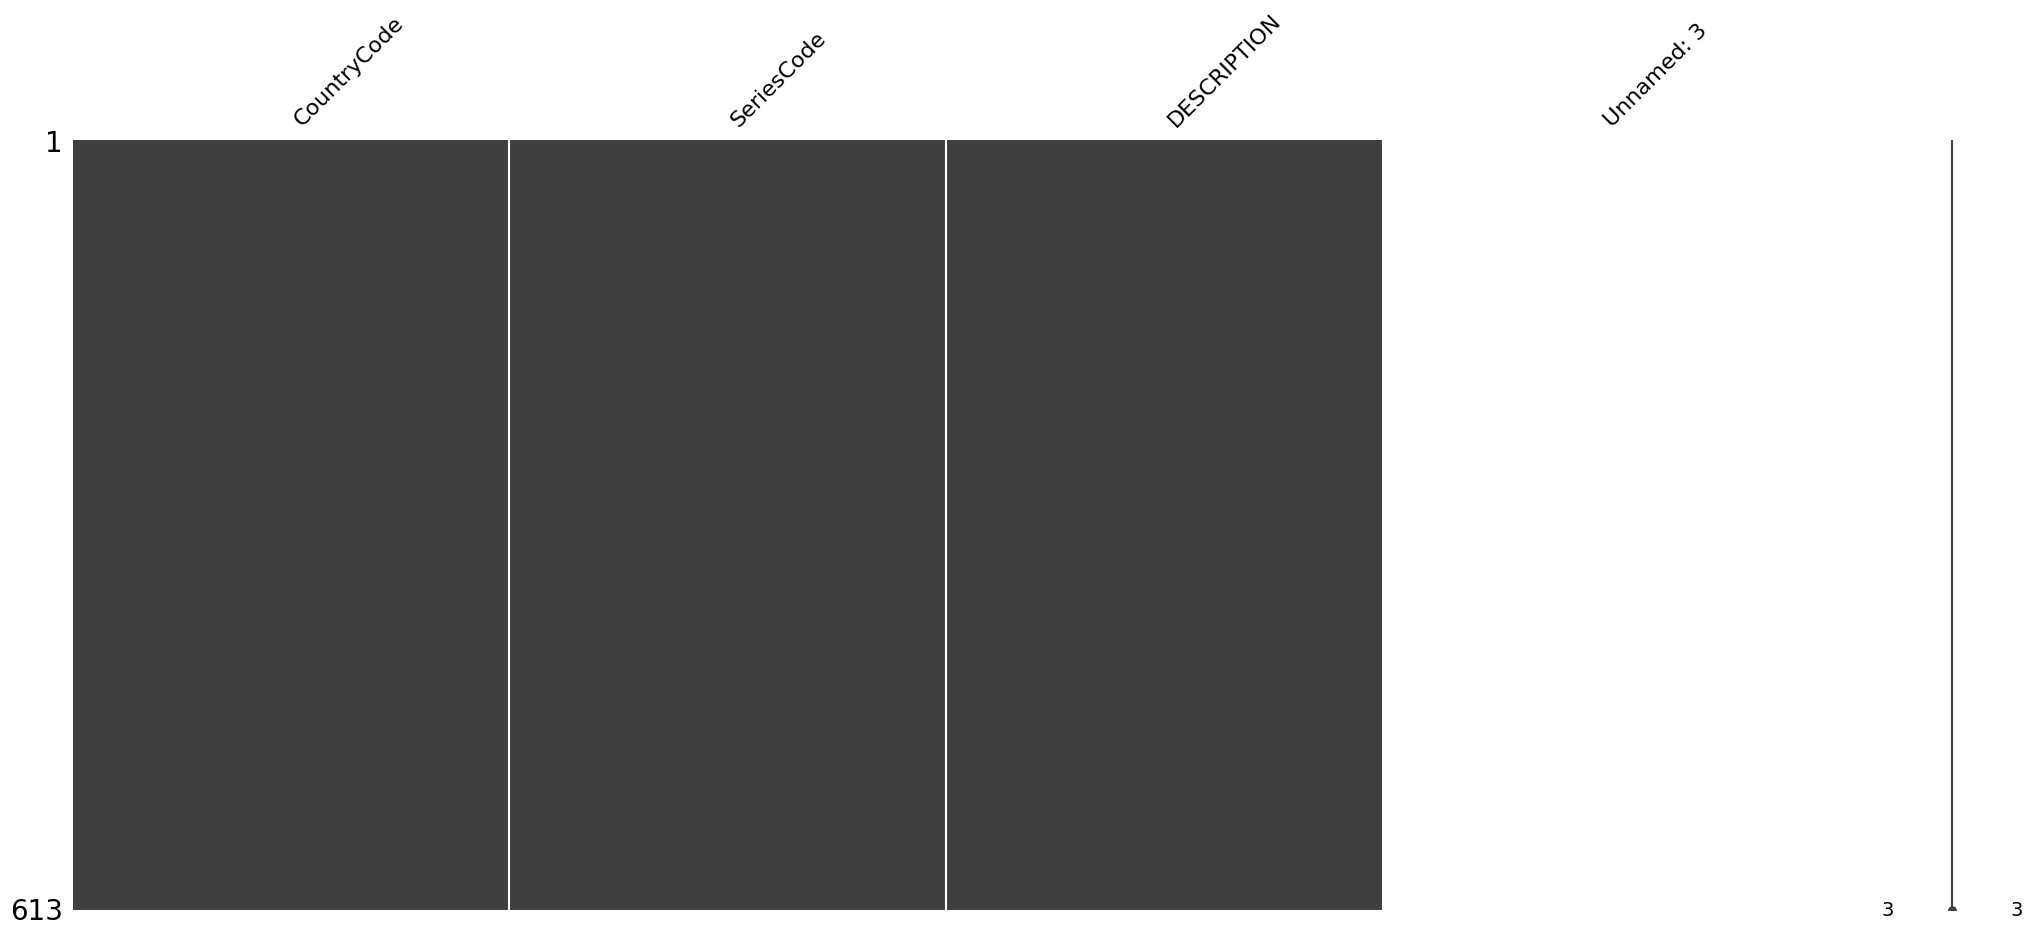

In [16]:
msno.matrix(country_series_df)
plt.show()

**Observations :**
- La colonne "Unnamed: 3" ne contient aucune information

#### 🧹 Nettoyage des colonnes inutiles

In [17]:
# Suppresion de la colonne "Unnamed: 3"
country_series_df = country_series_df.drop(columns=['Unnamed: 3'])
display(f"Taille avant et après la suppression des colonnes : {initial_shapes['country_series']} / {country_series_df.shape}")

'Taille avant et après la suppression des colonnes : (613, 4) / (613, 3)'

#### 🕵️ Analyse détaillée des colonnes

In [18]:
# Identifier les colonnes catégoriques et numériques
country_series_categorical_cols = country_series_df.select_dtypes(include=['object']).columns
display(country_series_categorical_cols, len(country_series_categorical_cols))


Index(['CountryCode', 'SeriesCode', 'DESCRIPTION'], dtype='object')

3

In [19]:
display(du.get_enhanced_info(country_series_df, verbose=True))

Analyzing 613 rows across 3 columns
Found 0 columns with missing values


,Column,Non-Null,Fill Rate (%),Unique Count,Dtype
0,CountryCode,613,100.0,211,object
1,SeriesCode,613,100.0,21,object
2,DESCRIPTION,613,100.0,97,object


**Observations :**
- Toutes les colonnes sont catégoriques.
- CountryCode contient le code de pays pour une indicateur disponible.

#### 🔎 Recherche de doublons

In [20]:
# Définir les colonnes clés pour la recherche de doublons logiques
country_series_key_columns = ['CountryCode', 'SeriesCode']
du.get_duplicates_in_subset(country_series_df, country_series_key_columns, verbose=True)

✓ No duplicates found


#### 🔢 Nombre d'occurrences pour les colonnes catégorielles

In [21]:
for col in country_series_categorical_cols:
    display(Markdown("---"))
    display(country_series_df[col].value_counts(dropna=False))

---

CountryCode
GEO    18
MDA    18
CYP    12
SRB    12
MUS    12
       ..
WSM     2
YEM     2
ZAF     2
ZMB     2
ZWE     2
Name: count, Length: 211, dtype: int64

---

SeriesCode
SP.POP.TOTL          211
SP.POP.GROW          211
NY.GDP.PCAP.PP.CD     19
NY.GNP.PCAP.PP.CD     19
NY.GDP.PCAP.PP.KD     19
NY.GNP.MKTP.PP.CD     14
NY.GDP.MKTP.PP.KD     14
NY.GDP.MKTP.PP.CD     14
SP.POP.1564.TO.ZS     13
SP.POP.TOTL.MA.ZS     13
SP.POP.TOTL.FE.ZS     13
SP.POP.0014.TO.ZS     13
NY.GNP.PCAP.CD         6
NY.GDP.PCAP.CD         5
NY.GDP.PCAP.KD         5
SP.POP.1564.MA.IN      4
SP.POP.0014.TO         4
SP.POP.1564.TO         4
SP.POP.1564.FE.IN      4
SP.POP.0014.MA.IN      4
SP.POP.0014.FE.IN      4
Name: count, dtype: int64

---

DESCRIPTION
Data sources : United Nations World Population Prospects                                              154
Data sources: United Nations World Population Prospects                                               137
Estimates are based on regression.                                                                     84
Data sources : Eurostat                                                                                54
Derived using ratio of age group from WPP and World Bank population.                                   24
                                                                                                     ... 
Data sources : U.S. Census Bureau, United Nations Population and Vital Statistics Report                1
Data sources: General Statistics Office of Vietnam                                                      1
Data sources : General Statistics Office of Vietnam                                                     1
Data sources : World Bank's Kosovo

#### ✅ Résumé de l'analyse initiale de `EdStatsCountry-Series`

Au cours de cette phase d'analyse exploratoire du DataFrame `country_series_df` (`EdStatsCountry-Series.csv`), les points clés suivants ont été observés :

- La visualisation MissingNo a montré que la colonne 'Unnamed: 3' est entièrement vide, par conséquent elle a été supprimé.
- Le DataFrame contient 3 colonnes catégoriques ('CountryCode', 'SeriesCode', 'DESCRIPTION') et aucune colonne numérique.
- L'analyse des occurrences des colonnes catégoriques a montré la distribution des différentes combinaisons Pays/Séries.
- Aucune ligne dupliquée n'a été trouvée, en tant que doublon logique basé sur la combinaison des colonnes clés ['CountryCode', 'SeriesCode'].

In [22]:
print(f"Shape initiale : {initial_shapes['country_series']}")
print(f"Shape finale : {country_series_df.shape}")

Shape initiale : (613, 4)
Shape finale : (613, 3)


### 2.5. ✨ Analyse de [EdStatsData]

#### 👀 Vue d'ensemble du dataset

In [23]:
display(Markdown(f"<center><strong> EdStatsData.csv {data_df.shape} </strong></center>"))
display(data_df.head(3))

<center><strong> EdStatsData.csv (886930, 70) </strong></center>

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 📌Identification et Classification des Types de Colonnes
Étant donné le grand nombre de colonnes dans le DataFrame `data_df` et la nature différente de l'analyse et du nettoyage requis pour les données numériques (années) et catégoriques, nous allons identifier et séparer ces types de colonnes dès maintenant. Cela facilitera les étapes ultérieures d'analyse détaillée, de traitement des valeurs manquantes et de préparation des données, en permettant d'appliquer des méthodes spécifiques à chaque ensemble de colonnes.

#### 🕵️ Analyse détaillée des colonnes

In [24]:
# Identifier les colonnes catégoriques et numériques
data_categorical_cols = data_df.select_dtypes(include=['object']).columns
data_numeric_cols = data_df.select_dtypes(include=['number']).columns

print("\nColonnes catégoriques:")
display(data_categorical_cols, len(data_categorical_cols))

print("\nColonnes numériques:")
display(data_numeric_cols, len(data_numeric_cols))


Colonnes catégoriques:


Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'], dtype='object')

4


Colonnes numériques:


Index(['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978',
       '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987',
       '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2020', '2025', '2030', '2035', '2040', '2045',
       '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090',
       '2095', '2100', 'Unnamed: 69'],
      dtype='object')

66

#### 🏷️Analyse des colonnes catégoriques

##### 🔢Nombre d'occurrences pour les colonnes catégorielles

In [25]:
# Affiche le nombre d'occurrences pour chaque valeur unique des colonnes catégoriques
for col in data_categorical_cols:
    print(f"\n--- Occurrences pour la colonne '{col}' ---")
    # Utiliser dropna=False pour inclure le compte des valeurs manquantes (si applicable)
    display(data_df[col].value_counts(dropna=False))


--- Occurrences pour la colonne 'Country Name' ---


Country Name
Arab World                                     3665
East Asia & Pacific                            3665
East Asia & Pacific (excluding high income)    3665
Euro area                                      3665
Europe & Central Asia                          3665
                                               ... 
Virgin Islands (U.S.)                          3665
West Bank and Gaza                             3665
Yemen, Rep.                                    3665
Zambia                                         3665
Zimbabwe                                       3665
Name: count, Length: 242, dtype: int64


--- Occurrences pour la colonne 'Country Code' ---


Country Code
ARB    3665
EAS    3665
EAP    3665
EMU    3665
ECS    3665
       ... 
VIR    3665
PSE    3665
YEM    3665
ZMB    3665
ZWE    3665
Name: count, Length: 242, dtype: int64


--- Occurrences pour la colonne 'Indicator Name' ---


Indicator Name
Adjusted net enrolment rate, lower secondary, both sexes (%)               242
Adjusted net enrolment rate, lower secondary, female (%)                   242
Adjusted net enrolment rate, lower secondary, gender parity index (GPI)    242
Adjusted net enrolment rate, lower secondary, male (%)                     242
Adjusted net enrolment rate, primary, both sexes (%)                       242
                                                                          ... 
Youth illiterate population, 15-24 years, male (number)                    242
Youth literacy rate, population 15-24 years, both sexes (%)                242
Youth literacy rate, population 15-24 years, female (%)                    242
Youth literacy rate, population 15-24 years, gender parity index (GPI)     242
Youth literacy rate, population 15-24 years, male (%)                      242
Name: count, Length: 3665, dtype: int64


--- Occurrences pour la colonne 'Indicator Code' ---


Indicator Code
UIS.NERA.2              242
UIS.NERA.2.F            242
UIS.NERA.2.GPI          242
UIS.NERA.2.M            242
SE.PRM.TENR             242
                       ... 
UIS.LP.AG15T24.M        242
SE.ADT.1524.LT.ZS       242
SE.ADT.1524.LT.FE.ZS    242
SE.ADT.1524.LT.FM.ZS    242
SE.ADT.1524.LT.MA.ZS    242
Name: count, Length: 3665, dtype: int64

##### 📊 Analyse visuel des colonnes catégoriques


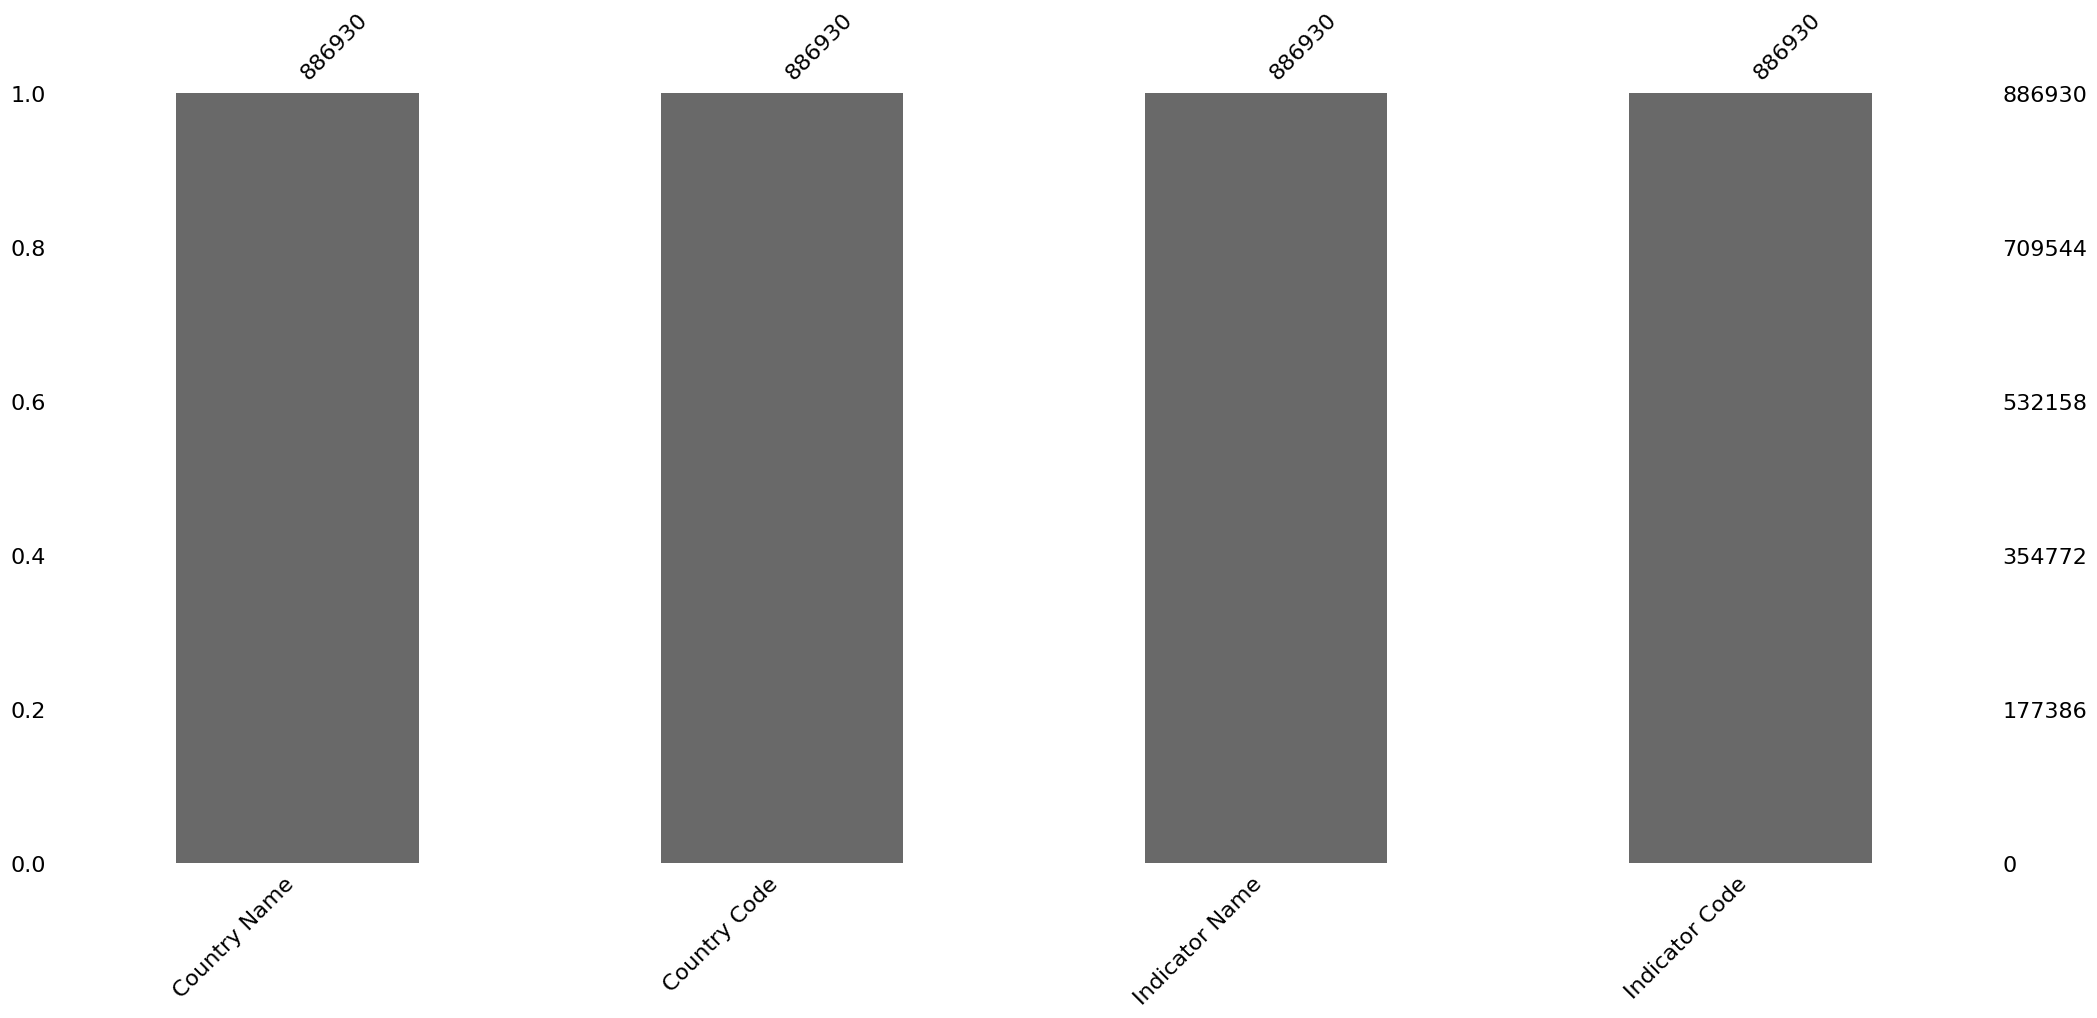

In [26]:
msno.bar(data_df[data_categorical_cols])
plt.show()

#### 📑 Profil des Colonnes : Complétude, Cardinalité et Types de Données"

In [27]:
du.get_enhanced_info(data_df[data_categorical_cols], verbose=True)

Analyzing 886930 rows across 4 columns
Found 0 columns with missing values


,Column,Non-Null,Fill Rate (%),Unique Count,Dtype
0,Country Name,886930,100.0,242,object
1,Country Code,886930,100.0,242,object
2,Indicator Name,886930,100.0,3665,object
3,Indicator Code,886930,100.0,3665,object


In [28]:
du.get_enhanced_info(data_df[data_numeric_cols],verbose=True)

Analyzing 886930 rows across 66 columns
Found 66 columns with missing values


,Column,Non-Null,Fill Rate (%),Unique Count,Dtype
40,2010,242442,27.33,135853,float64
35,2005,184108,20.76,123821,float64
30,2000,176676,19.92,115971,float64
42,2012,147264,16.60,130040,float64
41,2011,146012,16.46,128444,float64
...,...,...,...,...,...
1,1971,35537,4.01,30892,float64
3,1973,35545,4.01,30988,float64
46,2016,16460,1.86,12749,float64
47,2017,143,0.02,4,float64



**Observations :**
- Comme l'analyse des valeurs manquantes l'a montré, les colonnes représentant les années ont un pourcentage très élevé de valeurs manquantes.
- Cependant, pour l'instant, nous ne supprimerons pas ces colonnes malgré leur taux de complétude extrêment faible. Les données présentes pourraient être pertinentes pour des analyses ciblées sur certains pays ou indicateurs.

**Décision :**
- Pour cette étape, seule la colonne 'Unnamed: 69' sera supprimée car elle est totalement inutile. Les colonnes d'années seront conservées pour le moment.

#### 🧹 Nettoyage des colonnes inutiles


In [29]:
data_df = data_df.drop(columns=['Unnamed: 69'])
# Mettre à jour la liste de collonne numériques
data_numeric_cols = data_df.select_dtypes(include=['number']).columns
display(f"Taille avant et après la suppression des colonnes : {initial_shapes['data']} / {data_df.shape}")

'Taille avant et après la suppression des colonnes : (886930, 70) / (886930, 69)'

#### 🥇Analyse des colonnes numériques (Années)

In [30]:
# Afficher les statistiques descriptives pour les colonnes numériques
display(data_df[data_numeric_cols].describe())

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
count,7.228800e+04,3.553700e+04,3.561900e+04,3.554500e+04,3.573000e+04,8.730600e+04,3.748300e+04,3.757400e+04,3.757600e+04,3.680900e+04,...,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04
mean,1.974772e+09,4.253638e+09,4.592365e+09,5.105006e+09,5.401493e+09,2.314288e+09,5.731808e+09,6.124437e+09,6.671489e+09,7.436724e+09,...,7.145788e+02,7.224868e+02,7.271290e+02,7.283779e+02,7.266484e+02,7.228327e+02,7.176899e+02,7.113072e+02,7.034274e+02,6.940296e+02
std,1.211687e+11,1.804814e+11,1.914083e+11,2.059170e+11,2.112150e+11,1.375059e+11,2.215546e+11,2.325489e+11,2.473986e+11,2.660957e+11,...,2.136851e+04,2.215845e+04,2.287990e+04,2.352338e+04,2.408149e+04,2.455897e+04,2.496587e+04,2.530183e+04,2.556069e+04,2.574189e+04
min,-1.435564e+00,-1.594625e+00,-3.056522e+00,-4.032582e+00,-4.213563e+00,-3.658569e+00,-2.950945e+00,-3.174870e+00,-3.558749e+00,-2.973612e+00,...,-1.830000e+00,-1.630000e+00,-1.440000e+00,-1.260000e+00,-1.090000e+00,-9.200000e-01,-7.800000e-01,-6.500000e-01,-5.500000e-01,-4.500000e-01
25%,8.900000e-01,8.853210e+00,9.240920e+00,9.595200e+00,9.861595e+00,1.400000e+00,9.312615e+00,9.519913e+00,1.000000e+01,1.000000e+01,...,3.000000e-02,3.000000e-02,3.000000e-02,2.000000e-02,2.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02
50%,6.317724e+00,6.316240e+01,6.655139e+01,6.969595e+01,7.087760e+01,9.677420e+00,7.101590e+01,7.133326e+01,7.290512e+01,7.510173e+01,...,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.200000e-01
75%,6.251250e+01,5.655200e+04,5.863650e+04,6.202900e+04,6.383675e+04,7.854163e+01,5.682800e+04,5.739175e+04,5.940425e+04,6.411500e+04,...,7.500000e+00,7.505000e+00,7.500000e+00,7.300000e+00,7.100000e+00,6.722500e+00,6.080000e+00,5.462500e+00,4.680000e+00,4.032500e+00
max,1.903929e+13,1.986457e+13,2.100916e+13,2.238367e+13,2.282991e+13,2.300634e+13,2.424128e+13,2.521383e+13,2.622101e+13,2.730873e+13,...,2.813670e+06,2.951569e+06,3.070879e+06,3.169711e+06,3.246239e+06,3.301586e+06,3.337871e+06,3.354746e+06,3.351887e+06,3.330484e+06


#### 🔎 Recherche de doublons
  Définir les colonnes clés pour la recherche de doublons logiques dans data_df

  Une ligne unique devrait correspondre à un indicateur pour un pays à une année donnée.

  Pour une première vérification, utilisons Country Code et Indicator Code.
  
  Des doublons sur cette combinaison pourraient indiquer des entrées multiples pour le même indicateur/pays (potentiellement sur différentes années, ce qui nécessiterait un examen plus approfondi).

In [31]:
data_key_columns = ['Country Code', 'Indicator Code']
du.get_duplicates_in_subset(data_df, data_key_columns, verbose=True)

✓ No duplicates found


#### ✅ Résumé de l'analyse initiale de `EdStatsData`

Au cours de cette phase d'analyse exploratoire du DataFrame `data_df` (`EdStatsData.csv`), les points clés suivants ont été observés :

- Le DataFrame a été chargé avec succès et est de grande taille, avec une shape de (886930, 69).
- Une proportion très élevée de valeurs manquantes est présente dans de nombreuses colonnes, particulièrement dans les colonnes correspondant aux années.
- Le DataFrame contient 4 colonnes catégoriques ('Country Name', 'Country Code', 'Indicator Name', 'Indicator Code') et 65 colonnes numériques (principalement les années).
- L'analyse des occurrences pour les colonnes catégoriques a montré la distribution des indicateurs et des pays.
- Aucune ligne dupliquée n'a été trouvée en tant que doublon logique basé sur la combinaison des colonnes clés ['Country Code', 'Indicator Code'].
- La colonne 'Unnamed: 69', qui était totalement vide, a été supprimée.

Le DataFrame `data_df` est maintenant analysé pour sa structure et la qualité de ses données. La gestion des valeurs manquantes dans les colonnes d'années sera une étape cruciale lors du nettoyage.

### 2.6. ✨ Analyse de [EdStatsFootNote]

#### 👀 Vue d'ensemble du dataset

In [32]:
display(Markdown(f"<center><strong> EdStatsFootNote.csv {footnote_df.shape} </strong></center>"))
display(footnote_df.head(3))

<center><strong> EdStatsFootNote.csv (643638, 5) </strong></center>

,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,NaN


#### 📊 Analyse visuel avec la bibliothéque MissingNo

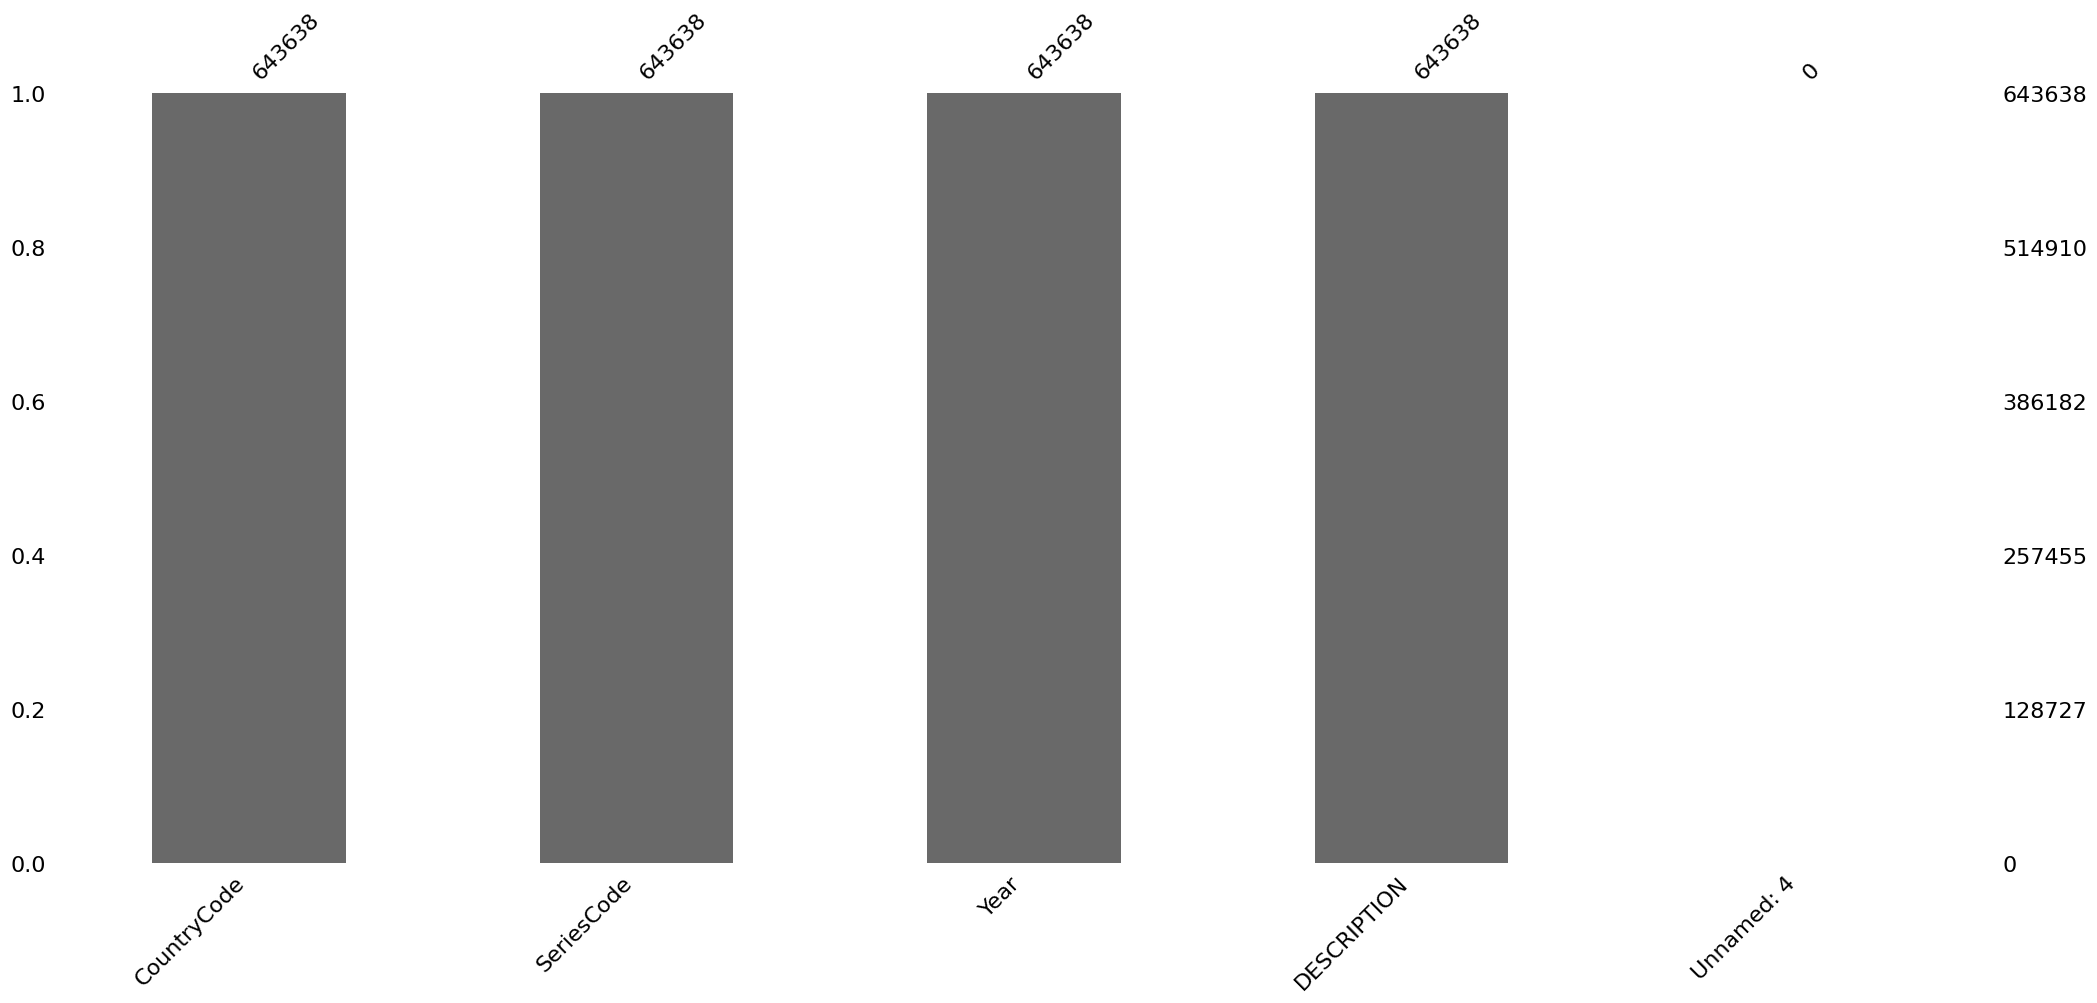

In [33]:
plt.figure(figsize=(10, 5))
msno.bar(footnote_df)
plt.show()

**Observations :**
- La colonne "Unnamed: 4" ne contient aucune information

#### 🧹 Nettoyage des colonnes inutiles

In [34]:
# Suppresion de la colonne "Unnamed: 4"
with track_dataframe_changes("footnote_df", "Suppression de la colonne 'Unnamed: 4"):
    footnote_df = footnote_df.drop(columns=["Unnamed: 4"])

Suppression de la colonne 'Unnamed: 4 avant: (643638, 5)
Suppression de la colonne 'Unnamed: 4 après: (643638, 4)
  🗑️  Colonnes supprimées: 1
  ⏱️  Temps: 0.0312s
----------------------------------------


#### 🕵️ Analyse détaillée des colonnes

In [35]:
# Affiche les colonnes catégoriques et numériques
footnote_categorical_cols = footnote_df.select_dtypes(include=['object']).columns
footnote_numeric_cols = footnote_df.select_dtypes(include=['number']).columns

print("\nColonnes catégoriques:")
display(footnote_categorical_cols, len(footnote_categorical_cols))

print("\nColonnes numériques:")
display(footnote_numeric_cols, len(footnote_numeric_cols))


Colonnes catégoriques:


Index(['CountryCode', 'SeriesCode', 'Year', 'DESCRIPTION'], dtype='object')

4


Colonnes numériques:


Index([], dtype='object')

0

#### 🏷️ Analyse des colonnes catégoriques

##### 🔢Nombre d'occurrences pour les colonnes catégorielles

In [36]:
# Affiche le nombre d'occurrences pour chaque valeur unique des colonnes catégoriques
for col in footnote_categorical_cols:
    display(Markdown("---"))
    display(footnote_df[col].value_counts(dropna=False))

---

CountryCode
LIC    7320
CYP    7183
LDC    6481
SSA    6389
SSF    6336
       ... 
IMN      32
CUW      23
XKX      12
MNP       4
FRO       2
Name: count, Length: 239, dtype: int64

---

SeriesCode
SH.DYN.MORT                  9226
SE.PRM.AGES                  8771
SE.PRM.DURS                  8771
SE.SEC.DURS                  8619
SE.SEC.AGES                  8581
                             ... 
NY.GNP.MKTP.PP.CD               1
NY.GNP.PCAP.PP.CD               1
UIS.AFR.SCHCENRESPR.23.PU       1
SL.UEM.TOTL.MA.ZS               1
UIS.XPubP.0                     1
Name: count, Length: 1558, dtype: int64

---

Year
YR2004    27128
YR2005    25992
YR2002    25687
YR2003    25683
YR2000    25093
YR2001    25047
YR2008    25018
YR1999    24938
YR2007    24263
YR2006    23394
YR2009    22965
YR2010    22598
YR2011    17760
YR1998    14916
YR2012    13890
YR2013    13405
YR1994    11448
YR2014    11378
YR1992    11309
YR1996    11197
YR1995    11194
YR1997    11167
YR1991    11129
YR1993    11093
YR1990    10616
YR1986     9743
YR1985     9653
YR1989     9517
YR1981     9465
YR1984     9386
YR1988     9382
YR1987     9357
YR1983     9227
YR1982     9014
YR1980     8950
YR1979     8742
YR1976     8729
YR1972     8661
YR1975     8627
YR1977     8593
YR1978     8585
YR1973     8571
YR1974     8512
YR1971     8507
YR2015     6348
YR1970     5374
YR2016      819
YR2017      558
YR2035      144
YR2050      144
YR2045      144
YR2040      144
YR2030      140
YR2025      140
YR2020      140
yr2012       14
Name: count, dtype: int64

---

DESCRIPTION
Country Data                                      191188
UNESCO Institute for Statistics (UIS) estimate    171527
Estimated                                         117155
UIS Estimation                                     31395
Country estimation.                                26308
                                                   ...  
Plausible bound is 12.5-16.1                           1
Uncertainty bound is 102.1 - 124.7                     1
Uncertainty bound is 100.9 - 118.9                     1
Uncertainty bound is 99.6 - 117.2                      1
Uncertainty bound is 127.1 - 148.2                     1
Name: count, Length: 9102, dtype: int64

#### 📑 Profil des Colonnes : Complétude, Cardinalité et Types de Données

In [37]:
du.get_enhanced_info(footnote_df[footnote_categorical_cols], verbose=True)

Analyzing 643638 rows across 4 columns
Found 0 columns with missing values


,Column,Non-Null,Fill Rate (%),Unique Count,Dtype
0,CountryCode,643638,100.0,239,object
1,SeriesCode,643638,100.0,1558,object
2,Year,643638,100.0,56,object
3,DESCRIPTION,643638,100.0,9102,object


#### 🥇 Analyse des colonnes numériques

In [38]:
if len(footnote_numeric_cols) > 0:
    display(footnote_df[footnote_numeric_cols].describe())
else:
    display(Markdown("Aucune colonne numérique dans ce DataFrame."))

Aucune colonne numérique dans ce DataFrame.

#### 🔎 Recherche de doublons

In [39]:
# Définir les colonnes clés pour la recherche de doublons logiques
# Assuming CountryCode, SeriesCode, and Year form a unique key for footnotes
footnote_key_columns = ['CountryCode', 'SeriesCode', 'Year']
du.get_duplicates_in_subset(footnote_df, footnote_key_columns, verbose=True)

✓ No duplicates found


#### ✅ Résumé de l'analyse initiale de `EdStatsFootNote`

Au cours de cette phase d'analyse exploratoire du DataFrame `footnote_df` (`EdStatsFootNote.csv`), les points clés suivants ont été observés :

- Une visualisation des valeurs manquantes (MissingNo) a montré que la colonne 'Unnamed: 4' est entièrement vide, par conséquent elle a été supprimé.
- Le DataFrame contient 4 colonnes catégoriques ('CountryCode', 'SeriesCode', 'Year', 'DESCRIPTION') et aucune colonne numérique.
- L'analyse des occurrences pour les colonnes catégoriques a montré la distribution des différentes combinaisons Pays/Séries/Années dans les notes de bas de page.
- Aucune ligne dupliquée n'a été trouvée, en tant que doublon logique basé sur la combinaison des colonnes clés ['CountryCode', 'SeriesCode', 'Year'].
- La colonne 'Unnamed: 4', qui était totalement vide, a été supprimée.

Le DataFrame `footnote_df` est maintenant analysé pour sa structure et la qualité de ses données.

### 2.7. ✨ Analyse de [EdStatsSeries]

#### 👀 Vue d'overview du dataset

In [40]:
display(Markdown(f"<center><strong> EdStatsSeries.csv {series_df.shape} </strong></center>"))
display(series_df.head(3))

<center><strong> EdStatsSeries.csv (3665, 21) </strong></center>

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 📊 Analyse visuel avec la bibliothéque MissingNo

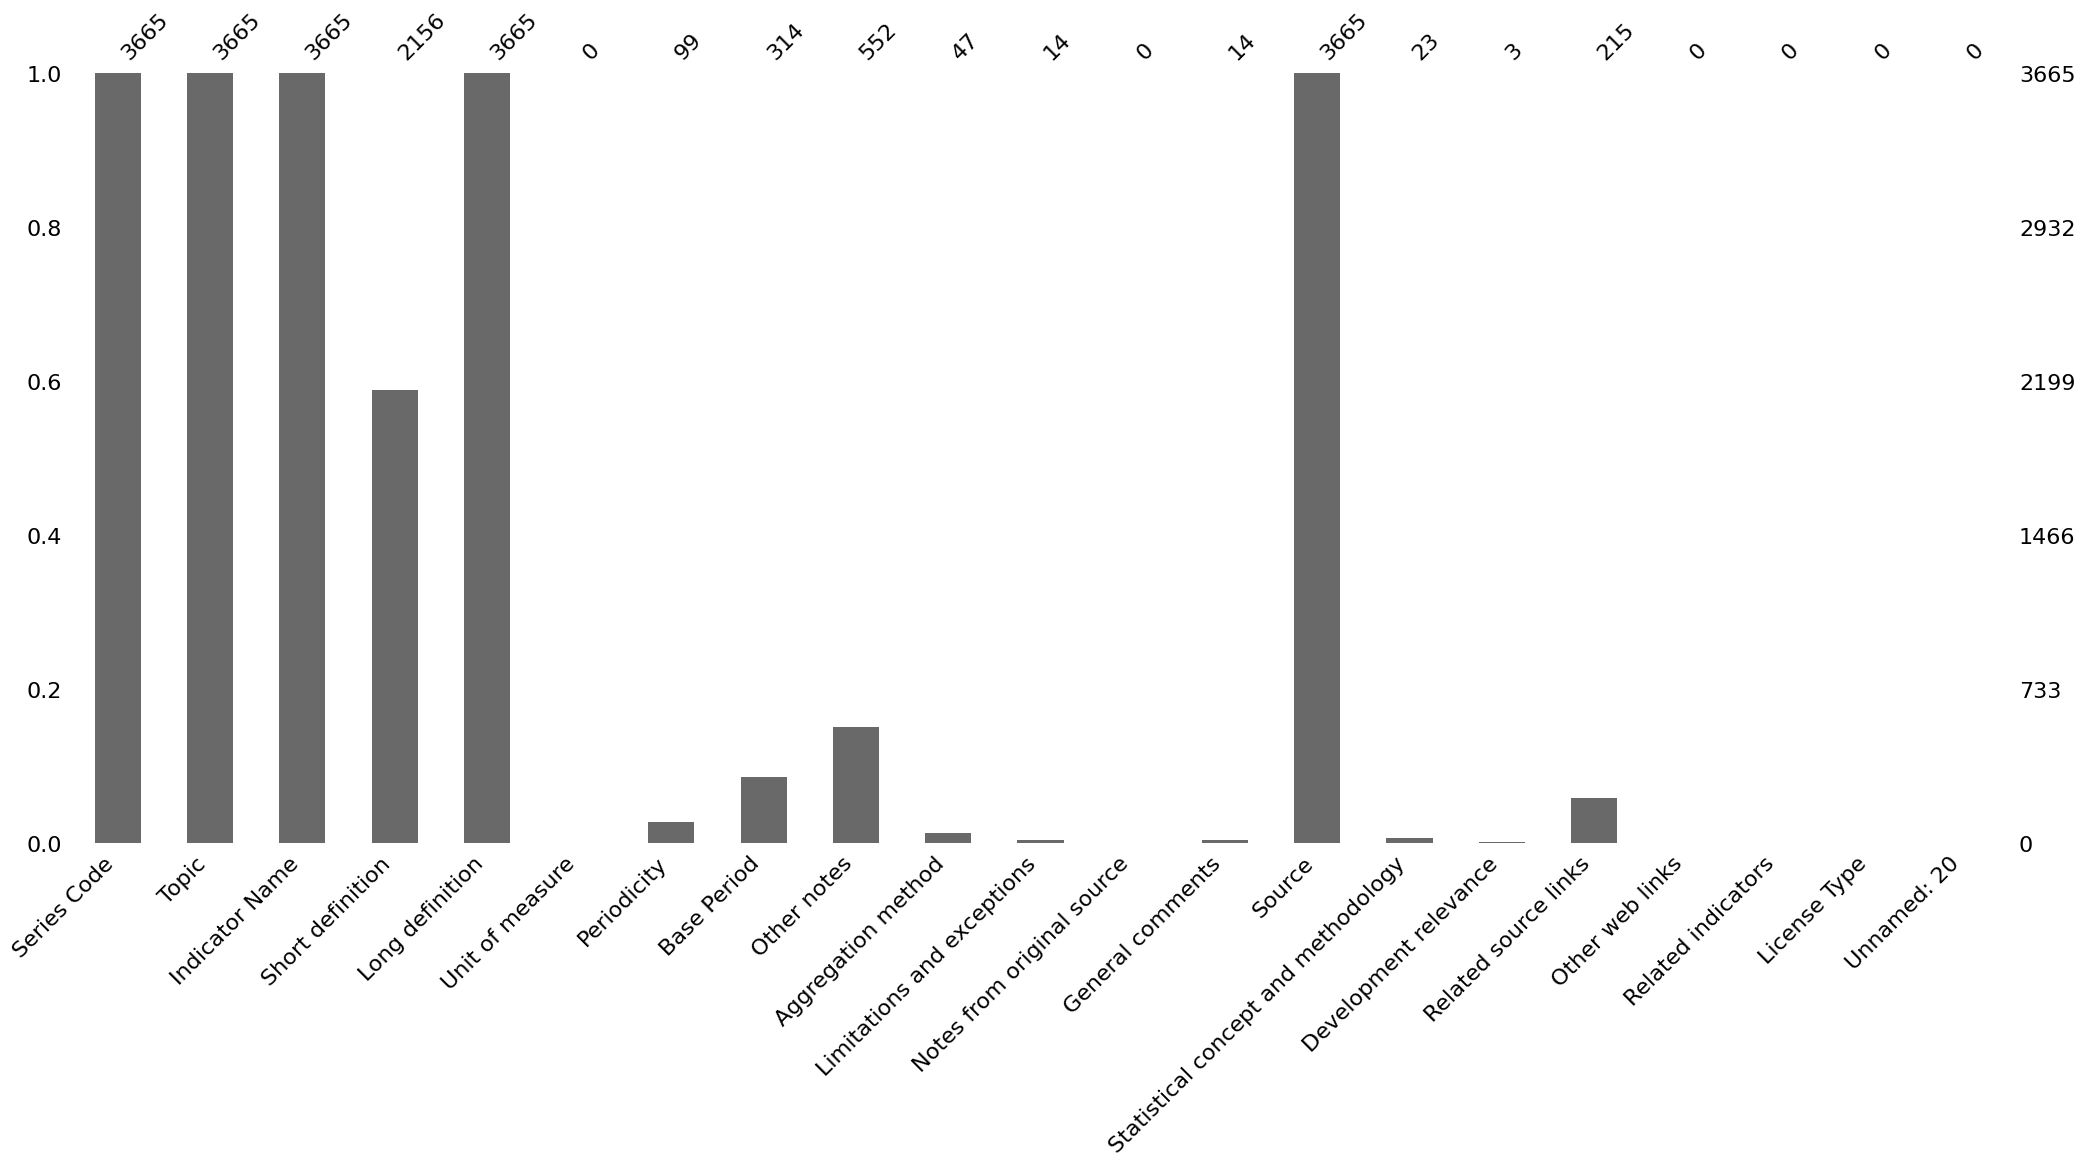

In [41]:
msno.bar(series_df)
plt.show()

In [42]:
# Detect columns with 100% of missing values
series_columns_to_drop = series_df.columns[series_df.isna().all()]
series_columns_to_drop

Index(['Unit of measure', 'Notes from original source', 'Other web links',
       'Related indicators', 'License Type', 'Unnamed: 20'],
      dtype='object')

**Observations :**

Les colonnes suivantes ne contiennent aucune information
  - Unit of measure
  - Notes from original source
  - Other web links
  - Related indicators
  - License Type
  - Unnamed: 20

#### 🧹 Nettoyage des colonnes inutiles

In [43]:
# Suppresion de la colonnes 100% vides
series_df = series_df.drop(columns=series_columns_to_drop)
display(f"Taille avant et après la suppression des colonnes : {initial_shapes['series']} / {series_df.shape}")

'Taille avant et après la suppression des colonnes : (3665, 21) / (3665, 15)'

#### 🕵️ Analyse détaillée des colonnes

In [44]:
# Affiche les colonnes catégoriques et numériques
series_categorical_cols = series_df.select_dtypes(include=['object']).columns
series_numeric_cols = series_df.select_dtypes(include=['number']).columns

print("\nColonnes catégoriques:")
display(series_categorical_cols, len(series_categorical_cols))

print("\nColonnes numériques:")
display(series_numeric_cols, len(series_numeric_cols))


Colonnes catégoriques:


Index(['Series Code', 'Topic', 'Indicator Name', 'Short definition',
       'Long definition', 'Periodicity', 'Base Period', 'Other notes',
       'Aggregation method', 'Limitations and exceptions', 'General comments',
       'Source', 'Statistical concept and methodology',
       'Development relevance', 'Related source links'],
      dtype='object')

15


Colonnes numériques:


Index([], dtype='object')

0

#### 🏷️ Analyse des colonnes catégoriques

##### 🔢Nombre d'occurrences pour les colonnes catégorielles

In [45]:
# Affiche le nombre d'occurrences pour chaque valeur unique des colonnes catégoriques
for col in series_categorical_cols:
    display(Markdown("---"))
    display(series_df[col].value_counts(dropna=False))

---

Series Code
BAR.NOED.1519.FE.ZS            1
BAR.NOED.1519.ZS               1
BAR.NOED.15UP.FE.ZS            1
BAR.NOED.15UP.ZS               1
BAR.NOED.2024.FE.ZS            1
                              ..
UIS.XUNIT.USCONST.3.FSGOV      1
UIS.XUNIT.USCONST.4.FSGOV      1
UIS.XUNIT.USCONST.56.FSGOV     1
XGDP.23.FSGOV.FDINSTADM.FFD    1
XGDP.56.FSGOV.FDINSTADM.FFD    1
Name: count, Length: 3665, dtype: int64

---

Topic
Learning Outcomes                                                                               1046
Attainment                                                                                       733
Education Equality                                                                               426
Secondary                                                                                        256
Primary                                                                                          248
Population                                                                                       213
Tertiary                                                                                         158
Teachers                                                                                         137
Expenditures                                                                                      93
Engaging the Private Sector (SABER)                                                  

---

...

Statistical concept and methodology
NaN                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   3642
TIMSS                                                    

---

Development relevance
NaN                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

---

Related source links
NaN                                     3450
http://saber.worldbank.org/index.cfm     215
Name: count, dtype: int64

#### 📑 Profil des Colonnes : Complétude, Cardinalité et Types de Données"

In [46]:
du.get_enhanced_info(series_df[series_categorical_cols], verbose=True)

Analyzing 3665 rows across 15 columns
Found 10 columns with missing values


,Column,Non-Null,Fill Rate (%),Unique Count,Dtype
0,Series Code,3665,100.00,3665,object
1,Topic,3665,100.00,37,object
2,Indicator Name,3665,100.00,3665,object
4,Long definition,3665,100.00,2060,object
11,Source,3665,100.00,31,object
3,Short definition,2156,58.83,1169,object
7,Other notes,552,15.06,14,object
6,Base Period,314,8.57,4,object
14,Related source links,215,5.87,1,object
5,Periodicity,99,2.70,1,object


#### 🥇 Analyse des colonnes numériques

In [47]:
if len(series_numeric_cols) > 0:
    display(series_df[series_numeric_cols].describe())
else:
    display(Markdown("Aucune colonne numérique dans ce DataFrame."))

Aucune colonne numérique dans ce DataFrame.

#### 🔎 Recherche de doublons

In [48]:
# Définir les colonnes clés pour la recherche de doublons logiques
# Assuming 'Series Code' is the unique key for series information
series_key_columns = ['Series Code']
du.get_duplicates_in_subset(series_df, series_key_columns, verbose=True)

✓ No duplicates found


#### ✅ Résumé de l'analyse initiale de `EdStatsSeries`

Au cours de cette phase d'analyse exploratoire du DataFrame `series_df` (`EdStatsSeries.csv`), les points clés suivants ont été observés :

- Une visualisation des valeurs manquantes (MissingNo) a montré que plusieurs colonnes sont entièrement vides ou contiennent un grand nombre de valeurs manquantes.
- Les colonnes 'Unit of measure', 'Notes from original source', 'Other web links', 'Related indicators', 'License Type', et 'Unnamed: 20' ont été identifiées comme totalement vides et supprimées.
- Le DataFrame contient plusieurs colonnes catégoriques et aucune colonne numérique.
- L'analyse des occurrences pour les colonnes catégoriques a montré la distribution des différentes séries.
- Aucune ligne dupliquée n'a été trouvée, en tant que doublon logique basé sur la colonne clé ['Series Code'].

Le DataFrame `series_df` est maintenant analysé pour sa structure et la qualité de ses données.

In [49]:
print(f"Shape initiale : {initial_shapes['series']}")
print(f"Shape finale : {series_df.shape}")

Shape initiale : (3665, 21)
Shape finale : (3665, 15)


### 2.8. 🌍 Détection de faux pays

**Incohérence dans le nombre d'entités :**

Notre dataset contient **241 entrées** dans la colonne `"Short Name"`, ce qui suggère la présence de faux pays, d'agrégations régionales et d'entités non reconnues.

**Solutions envisagées :**

- Éliminer les pays ayant une valeur manquante dans la colonne `"Currency Unit"`  
- Effectuer un tri manuel

**Choix effectué :**

J'ai opté pour le tri manuel afin d'obtenir un résultat plus précis.

**Résultat du nettoyage :**

- **25 entités supprimées** : agrégations régionales (ex: "Europe & Central Asia"), groupes économiques (ex: "High income") et entités mondiales (ex: "World")
- **216 entités conservées** : pays souverains + territoires autonomes (ex: Hong Kong, Macao) + entités économiques distinctes
- Ce nombre est cohérent avec les standards des datasets internationaux (World Bank, OECD)

In [50]:
country_df["Long Name"].nunique()

241

In [51]:
country_df["Region"].unique()

array(['Latin America & Caribbean', 'South Asia', 'Sub-Saharan Africa',
       'Europe & Central Asia', nan, 'Middle East & North Africa',
       'East Asia & Pacific', 'North America'], dtype=object)

In [52]:
country_df.columns

Index(['Country Code', 'Short Name', 'Table Name', 'Long Name', '2-alpha code',
       'Currency Unit', 'Special Notes', 'Region', 'Income Group', 'WB-2 code',
       'National accounts base year', 'National accounts reference year',
       'SNA price valuation', 'Lending category', 'Other groups',
       'System of National Accounts', 'Alternative conversion factor',
       'PPP survey year', 'Balance of Payments Manual in use',
       'External debt Reporting status', 'System of trade',
       'Government Accounting concept', 'IMF data dissemination standard',
       'Latest population census', 'Latest household survey',
       'Source of most recent Income and expenditure data',
       'Vital registration complete', 'Latest agricultural census',
       'Latest industrial data', 'Latest trade data',
       'Latest water withdrawal data'],
      dtype='object')

In [53]:
# Les faux pays détecté manuellement de 'Short Name'
country_fake_short_names = {
    "Arab World",
    "East Asia & Pacific (developing only)",
    "East Asia & Pacific (all income levels)",
    "Europe & Central Asia (developing only)",
    "Europe & Central Asia (all income levels)",
    "Euro area",
    "European Union",
    "High income",
    "Heavily indebted poor countries (HIPC)",
    "Latin America & Caribbean (developing only)",
    "Latin America & Caribbean (all income levels)",
    "Least developed countries: UN classification",
    "Low income",
    "Lower middle income",
    "Low & middle income",
    "Middle East & North Africa (all income levels)",
    "Middle income",
    "Middle East & North Africa (developing only)",
    "North America",
    "OECD members",
    "South Asia",
    "Sub-Saharan Africa (developing only)",
    "Sub-Saharan Africa (all income levels)",
    "Upper middle income",
    "World"
}
len(country_fake_short_names)

25

In [54]:
data_df["Country Code"].nunique(), country_df["Country Code"].nunique(), footnote_df["CountryCode"].nunique(),country_series_df["CountryCode"].nunique()    

(242, 241, 239, 211)

#### 2.8.1. Filtrer [EdStatsCountry]

In [55]:
with track_dataframe_changes("country_df", "Suppression des faux pays"):
    # country_df[~country_df["Short Name"].isin(country_fake_short_names)]
    country_df = country_df.query("`Short Name` not in @country_fake_short_names")

Suppression des faux pays avant: (241, 31)
Suppression des faux pays après: (216, 31)
  ✂️  Lignes supprimées: 25
  ⏱️  Temps: 0.0097s
----------------------------------------


#### 2.8.2. Filtrer [EdStatsCountry-Series]

In [56]:
with track_dataframe_changes("country_series_df", "Suppression des faux pays"):
    country_series_df = (
        country_series_df
        .merge(country_df["Country Code"], left_on="CountryCode", right_on="Country Code", how="inner")
        .drop(columns="Country Code")
    )

Suppression des faux pays avant: (613, 3)
Suppression des faux pays après: (613, 3)
  🔄 Aucun changement de dimension
  ⏱️  Temps: 0.0034s
----------------------------------------


#### 2.8.3. Filtrer [EdStatsData]

In [57]:
with track_dataframe_changes("data_df", "Suppression des faux pays"):
    data_df = data_df.merge(country_df["Country Code"], on="Country Code", how="inner")

Suppression des faux pays avant: (886930, 69)
Suppression des faux pays après: (791640, 69)
  ✂️  Lignes supprimées: 95290
  ⏱️  Temps: 0.4481s
----------------------------------------


#### 2.8.4. Filtrer [EdStatsFootNote]

In [58]:
with track_dataframe_changes("footnote_df", "Suppression des faux pays"):
    footnote_df = footnote_df.merge(country_df["Country Code"], left_on="CountryCode", right_on="Country Code", how="inner").drop(columns=["Country Code"])

Suppression des faux pays avant: (643638, 4)
Suppression des faux pays après: (518109, 4)
  ✂️  Lignes supprimées: 125529
  ⏱️  Temps: 0.1753s
----------------------------------------


| DataFrame     | Taille initiale  | Taille après filtrage   | Lignes supprimées
| ------------- | ------------- | ------------- | -------------
| EdStatsCountry | (241, 31) | (216, 31)| 25 
| EdStatsCountry-Series | (613, 3) | (613, 3)|0
| EdStatsData |(886 930, 69) | (791 640, 69)|95 290
|EdStatsFootNote|(643 638, 4)|(518 109, 4)|125 529



### 2.9. 🗜️Utilité de la table EdStatsCountry-Series

**Contexte** :  
Il existe de nombreuses paires (Pays, Indicateur) dans la table `EdStatsData`, mais la plupart présentent des données manquantes. La table `EdStatsCountry-Series` référence une sous-liste restreinte de ces paires.

**Hypothèse** :  
Les couples (Pays, Indicateur) présents dans `EdStatsCountry-Series` devraient correspondre à des séries mieux remplies et plus fiables dans `EdStatsData`.

**Résultats** :  
- Taux moyen de remplissage pour les paires présentes dans `EdStatsCountry-Series` : **63.93 %**
- Taux moyen de remplissage pour les paires absentes : **8.78 %**
- Toutes les paires référencées par `EdStatsCountry-Series` existent dans `EdStatsData`.

Cette différence significative confirme que la table `EdStatsCountry-Series` permet d’identifier les combinaisons possédant un bon niveau de complétion des données dans la base principale.

**Conclusion** :  
Pour obtenir des analyses fiables, il est pertinent de filtrer les données selon la présence des couples (pays, indicateur) dans `EdStatsCountry-Series`, ou d’utiliser le taux de complétion comme critère de sélection.


#### 2.9.1. Vérifier la structure des combinaisons pays/séries

In [59]:
# Confirmer la structure
print(f"Indicateurs uniques: {len(country_series_df['SeriesCode'].unique())}") 
print(f"Pays uniques: {len(country_series_df['CountryCode'].unique())}")  
print(f"Total combinaisons: {len(country_series_df)}")  

Indicateurs uniques: 21
Pays uniques: 211
Total combinaisons: 613


#### 2.9.2. Harmoniser les noms de colonnes

In [60]:
country_series_df_renamed = country_series_df.rename(
    columns = {"CountryCode": "Country Code", "SeriesCode" : "Indicator Code" }
)

#### 2.9.3. Préparer la jointure entre les tables

In [61]:
data_all_years = [col for col in data_df.columns if col.isdigit()]
data_df["Year Coverage Rate"] = data_df[data_all_years].notna().mean(axis=1).mul(100).round(2)
data_df[["Country Name","Indicator Code", "Year Coverage Rate"]].sort_values(by="Year Coverage Rate", ascending=False).head()

,Country Name,Indicator Code,Year Coverage Rate
291846,Guinea,SP.SEC.LTOT.IN,72.31
192900,Denmark,SP.PRM.TOTL.IN,72.31
291859,Guinea,SP.SEC.TOTL.FE.IN,72.31
265130,Ghana,NY.GNP.MKTP.CD,72.31
717208,Trinidad and Tobago,SP.POP.TOTL,72.31


#### 2.9.4. Analyser la présence des couples dans EdStatsData

In [62]:
merge_cs_data_df = data_df.merge(
                            country_series_df_renamed[["Country Code", "Indicator Code"]],
                            on=["Country Code", "Indicator Code"], 
                            how="left",
                            indicator=True # d'où vien chaque ligne
)

In [63]:
in_series = merge_cs_data_df[merge_cs_data_df["_merge"] == "both"]

missing_series_count = country_series_df.shape[0] - in_series.shape[0]
if missing_series_count == 0:
    print("\n✓ Toutes les lignes de country_series_df sont presentes dans data_df")
else:
    print(f"✗ {missing_series_count} lignes sont absente(s) dans data_df")

display(in_series[['Country Code', 'Indicator Code', 'Year Coverage Rate']].head())


✓ Toutes les lignes de country_series_df sont presentes dans data_df


,Country Code,Indicator Code,Year Coverage Rate
1246,AFG,NY.GDP.PCAP.PP.KD,23.08
1247,AFG,NY.GDP.PCAP.PP.CD,23.08
1248,AFG,NY.GDP.MKTP.PP.KD,23.08
1249,AFG,NY.GDP.MKTP.PP.CD,23.08
1252,AFG,NY.GNP.PCAP.PP.CD,23.08


**Intégrité des données vérifiée :**  
✓ Toutes les lignes de `EdStatsCountry-Series` sont présentes dans `EdStatsData`.

Cela signifie que pour chaque couple (pays, indicateur) sélectionné comme pertinent dans `EdStatsCountry-Series`, on dispose effectivement de données correspondantes dans la table principale. Cela garantit la cohérence des analyses effectuées à partir de cette sélection.


In [64]:
not_in_series = merge_cs_data_df[merge_cs_data_df['_merge'] == 'left_only']
print(f"Lignes absentes de Country Series : {not_in_series.shape[0]}")
display(not_in_series[['Country Code', 'Indicator Code', 'Year Coverage Rate']].head())

Lignes absentes de Country Series : 791027


,Country Code,Indicator Code,Year Coverage Rate
0,AFG,UIS.NERA.2,7.69
1,AFG,UIS.NERA.2.F,7.69
2,AFG,UIS.NERA.2.GPI,7.69
3,AFG,UIS.NERA.2.M,7.69
4,AFG,SE.PRM.TENR,0.00


#### 2.9.5. Comparer les taux de complétion

In [65]:
print("Taux moyen de remplissage pour les paires présentes :",
      in_series['Year Coverage Rate'].mean().round(2), "%")
print("Taux moyen de remplissage pour les paires absentes :",
      not_in_series['Year Coverage Rate'].mean().round(2), "%")

Taux moyen de remplissage pour les paires présentes : 63.93 %
Taux moyen de remplissage pour les paires absentes : 9.27 %


### 2.10. Fiabilisation des Données (Cohérence entre EdStatsData et EdStatsSeries)
> Après le nettoyage individuel des fichiers, cette étape cruciale vérifie la cohérence entre la table des données (`EdStatsData`) et celle des descriptions d'indicateurs (`EdStatsSeries`). L'objectif est de s'assurer que chaque indicateur utilisé dans l'analyse est correctement défini.

#### 2.10.1. Vérification Initiale de la Cohérence
La première étape consiste à comparer le nombre d'indicateurs uniques dans chaque dataframe.

**Constat :**
- Le nombre total d'indicateurs **uniques** est identique dans les deux tables **3665**.
- Cela suggère une bonne cohérence globale, mais ne garantit pas que les ensembles de codes sont parfaitement identiques.

In [66]:
data_indicator_set = set(data_df["Indicator Code"].unique())
series_set = set(series_df["Series Code"].unique())

display(Markdown(f"Code d'indicateurs uniques dans **EdStatsData:** {len(data_indicator_set)}"))
display(Markdown(f"Code d'indicateurs uniques dans **EdStatsSeries:** {len(series_set )}"))

Code d'indicateurs uniques dans **EdStatsData:** 3665

Code d'indicateurs uniques dans **EdStatsSeries:** 3665

#### 2.10.2. Détection des Incohérences (Codes "Orphelins")
Une comparaison plus approfondie est menée pour identifier les codes qui ne sont pas présents dans les deux ensembles.

In [67]:
orphelin_data_indicators = data_indicator_set - series_set
print(f"Indicateurs sans description: {len(orphelin_data_indicators)}")

orphelin_series = series_set - data_indicator_set
print(f"Descriptions sans données : {len(orphelin_series)}")

Indicateurs sans description: 53
Descriptions sans données : 53


**Anomalies détectées : casse non uniforme et espaces parasites**
* DATA : `UIS.SLE.1T6.GPI` (majuscules)
* SERIES : `UIS.SLE.1t6.GPI` (minuscules)
* SERIES : `'SE.SEC.DURS.LO '` (espace final)

#### 2.10.3. Correction et Validation
Une normalisation est appliquée pour résoudre ces problèmes, suivie d'une validation finale.

**Conclusion :**

- ✓ Cohérence parfaite : La base de données est maintenant fiabilisée et prête pour la sélection des indicateurs.

In [68]:
data_df["Indicator Code"] = data_df["Indicator Code"].str.strip().str.upper()
series_df["Series Code"] = series_df["Series Code"].str.strip().str.upper()

In [69]:
data_indicator_set = set(data_df["Indicator Code"].unique())
series_set = set(series_df["Series Code"].unique())

if len(data_indicator_set) == len(series_set):
    print("✓ Nombre des indicateurs uniques matchent")

orphelin_data_indicators = data_indicator_set - series_set
if len(orphelin_data_indicators) == 0:
    print("✓ Aucun indicateurs sans description")
else:
    print(f"Indicateurs sans description: {len(orphelin_data_indicators)}")

orphelin_series = series_set - data_indicator_set
if len(orphelin_series) == 0:
    print("✓ Aucune description sans données")
else:
    print(f"✗ Descriptions sans données : {len(orphelin_series)}")

✓ Nombre des indicateurs uniques matchent
✓ Aucun indicateurs sans description
✓ Aucune description sans données


## 3. Analyse Préliminaire des Indicateurs
Avant de procéder à une sélection, une analyse préliminaire a été menée sur l'ensemble des 3665 indicateurs pour comprendre leur structure, leur disponibilité et leur répartition.

### 3.1. Structure et Disponibilité Globale
- Une première vérification a été effectuée pour confirmer que chaque pays dispose du même nombre d'indicateurs potentiels dans la base de données brute.
- L'absence de valeurs manquantes dans la colonne `Indicator Code` confirme que chaque ligne de `data_df` est bien associée à un indicateur.

In [70]:
# Examinons le nombre d'indicator pour un pays spécifique.
mask = data_df["Country Name"] == "Turkey"
data_df[mask][["Country Name","Country Code"]].shape

(3665, 2)

In [71]:
# Maintenant pour chaque pays.
data_df.groupby("Country Code")["Indicator Code"].nunique().unique()
# Le resultat nous indique qu'on a 3665 indicator pour chauqe pays sans exception et aucune valeur NaN

array([3665])

In [72]:
# Aucune valeur manquante
data_df["Indicator Code"].isna().any()

np.False_

### 3.2. Analyse de la Complétude Temporelle
Le taux de remplissage a été calculé pour chaque colonne d'année. Le résultat montre que les données sont plus complètes pour les années récentes (ex: 2010), tandis que les années plus anciennes et très récentes (2016, 2017) sont beaucoup moins renseignées. Cette disparité justifiera plus tard le choix de se concentrer sur une période restreinte.

In [73]:
# Pourcentage de valeurs manquants dans les données annuelles
data_df[data_numeric_cols].isna().mean().round(2).sort_values()

2010    0.71
2005    0.78
2000    0.79
2009    0.83
2006    0.83
        ... 
1981    0.96
1982    0.96
1984    0.96
2016    0.98
2017    1.00
Length: 65, dtype: float64

### 3.3. Analyse de la Couverture par Pays dans `EdStatsCountry-Series`
La table `EdStatsCountry-Series` ne contient pas tous les indicateurs pour chaque pays. L'analyse montre une grande disparité : certains pays n'ont que 2 indicateurs référencés, tandis que d'autres en ont jusqu'à 18. Cette table semble donc identifier une sous-sélection d'indicateurs considérés comme particulièrement pertinents ou fiables pour certains pays.

In [74]:
# Indicateurs disponible par pays
country_series_df.groupby("CountryCode")["SeriesCode"].nunique().sort_values()

CountryCode
ABW     2
AGO     2
ALB     2
AND     2
ARM     2
       ..
MAR    12
CYP    12
TZA    12
GEO    18
MDA    18
Name: SeriesCode, Length: 211, dtype: int64

## 4. Réduction du périmètre par approche métier : Sélection Stratégique des Indicateurs
Cette section détaille la méthodologie en plusieurs étapes 
- pour passer de plus de `3665` indicateurs à une sélection finale, 
    - en combinant une approche métier
    - et une analyse statistique

### 4.1. Définition d'une Stratégie de Sélection Mixte
**Contexte:**
On cherche à choisir un pays où s’implanter. On cible donc des indicateurs qui aident à évaluer le potentiel d’un pays pour l’expansion d’une entreprise dans le secteur de l’éducation.

🎯 **Stratégie de sélection des indicateurs**

**Problématique**
Comment faire un choix pertinent et équilibré ?

**Approche développée : Double stratégie**

1️⃣ **Stratégie de priorisation (3 niveaux)**
Contrairement à l'approche binaire classique (pertinent/non-pertinent), j'ai opté pour **3 niveaux de priorité** :

- 🟢 HIGH priority : Topics cœur de métier → Priorité absolue
- 🔶 **MEDIUM priority** : Topics intéressants → Garde de sécurité
- 🚫 **LOW priority** : Topics sans lien avec le métier → Suppression directe


**Avantage** : Flexibilité ! Si pas assez d'indicateurs HIGH qualité, fallback possible sur MEDIUM.

2️⃣ **Stratégie de diversification thématique (inspirée PESTEL)**
Pour éviter un portfolio déséquilibré, application du principe PESTEL :
- **Grouper les indicateurs selectionnés par topics et sélectioner les meilleurs indicateurs de chaque topics** (diversification)
- **Seuil qualité minimum** (Par exemple ≥150 pays avec données)
- **Résultat** : Portfolio équilibré de 5-6 topics différents

**Objectif final**
Obtenir une sélection d'indicateurs à la fois :
-  **Riche en données** (critère quantitatif)
-  **Diversifiée thématiquement** (critère qualitatif)
-  **Pertinente métier** (critère business)



### 4.2. Filtre 1 : Sélection par Pertinence Métier (Topics)
> Conformément à la stratégie définie, la première étape a consisté à ne conserver que les catégories d'indicateurs (`Topics`) en lien avec les objectifs d'Academy.

#### 4.2.1. Identifier la colonne "catégorie métier"
Dans le jeu de données `EdStatsSeries`(series_df), la colonne `Topic` décrit la catégorie métier à laquelle appartient chaque indicateur.

#### 4.2.2. Garder les catégories pertinentes

In [75]:
all_topics = series_df["Topic"].unique()
for topic in all_topics:
    print(topic)
print(f"\n { len(all_topics) } catégories trouvés")

Attainment
Education Equality
Infrastructure: Communications
Learning Outcomes
Economic Policy & Debt: National accounts: US$ at current prices: Aggregate indicators
Economic Policy & Debt: National accounts: US$ at constant 2010 prices: Aggregate indicators
Economic Policy & Debt: Purchasing power parity
Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita
Teachers
Education Management Information Systems (SABER)
Early Child Development (SABER)
Engaging the Private Sector (SABER)
School Health and School Feeding (SABER)
School Autonomy and Accountability (SABER)
School Finance (SABER)
Student Assessment (SABER)
Teachers (SABER)
Tertiary Education (SABER)
Workforce Development (SABER)
Literacy
Background
Primary
Secondary
Tertiary
Early Childhood Education
Pre-Primary
Expenditures
Health: Risk factors
Health: Mortality
Social Protection & Labor: Labor force structure
Laber
Social Protection & Labor: Unemployment
Health: Population: Structure
Population
Health: Populati

#### 4.2.3. Clarification des catégories
Certains noms de catégories ne reflètent pas suffisamment les informations qu'elles contiennent. Après examen :

- La catégorie `Background` contient deux indicateurs sur la scolarité obligatoire (durée et âge de début). Bien que leur pertinence ne soit pas prioritaire, ils apportent un contexte utile.
- La catégorie `Laber` présente une faute de frappe. Elle contient trois indicateurs très pertinents sur les jeunes n'étant ni en étude, ni en emploi, ni en formation `NEET`, qui représentent des clients potentiels.
**Décisions :**
  
1. La catégorie `Background` est conservée.
1. La catégorie `Laber` sera renommée en `Social Protection & Labor: Unemployment`.

In [76]:
pd.set_option("display.max_colwidth", 70)
series_df.query("(Topic == 'Background') or (Topic == 'Laber')")[["Topic", "Series Code", "Long definition", "Other notes"]]

,Topic,Series Code,Long definition,Other notes
2216,Background,SE.COM.DURS,Number of years that children are legally obliged to attend school.,NaN
2395,Laber,SL.UEM.NEET.FE.ZS,"Share of youth not in education, employment or training (NEET) is ...",Social Protection & Labor: Unemployment
2396,Laber,SL.UEM.NEET.MA.ZS,"Share of youth not in education, employment or training (NEET) is ...",Social Protection & Labor: Unemployment
2397,Laber,SL.UEM.NEET.ZS,"Share of youth not in education, employment or training (NEET) is ...",Social Protection & Labor: Unemployment
2724,Background,UIS.CEAGE.1,Official age when students should enter compulsory education assum...,NaN


In [77]:
# Renommer la catégorie 'Laber' en 'Social Protection & Labor: Unemployment'
print(f"Nombre de catégorie avant: {series_df['Topic'].nunique()}")
series_df.loc[ series_df["Topic"] == "Laber", 'Topic'] = "Social Protection & Labor: Unemployment"
print(f"Nombre de catégorie après: {series_df['Topic'].nunique()}")

Nombre de catégorie avant: 37
Nombre de catégorie après: 36


#### 4.2.4. Selection des catégories pertinentes

In [78]:
# Liste des catégories à HAUTE priorité (impact direct et stratégique)
high_priority_topics = [    
    'Infrastructure: Communications', # Prérequis technique : les clients potentiels peuvent-ils accéder à un service en ligne ?
    'Learning Outcomes',  # Indicateur du besoin : la qualité de l'éducation actuelle justifie-t-elle une offre complémentaire ?
    'Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita', # Solvabilité du marché : la population a-t-elle les moyens de payer pour le service ?
    'Economic Policy & Debt: Purchasing power parity',# Affordabilité réelle : complément du GNI pour mieux évaluer le pouvoir d'achat local.
    'Secondary', # Cœur de cible n°1 : mesure directe du marché potentiel niveau lycée.
    'Tertiary', # Cœur de cible n°2 : mesure directe du marché potentiel niveau université.
    'Expenditures', # Volonté de payer : mesure des dépenses actuelles (publiques/privées) en éducation.
    'Population', # Taille brute du marché : nombre total d'habitants pour évaluer l'échelle potentielle.
    'Health: Population: Dynamics', # Potentiel de croissance : le nombre de jeunes (futurs clients) va-t-il augmenter ou diminuer ?
    'Health: Population: Structure', # Taille du marché cible : quantification de la population dans les tranches d'âges clés (ex: 15-24 ans).
]
display(Markdown(f"**{len(high_priority_topics)}** catégorie(s) selectionnée(s) en **priorité elevé**"))

**10** catégorie(s) selectionnée(s) en **priorité elevé**

In [79]:
relevant_topics = [
    # Prérequis technique : les clients potentiels peuvent-ils accéder à un service en ligne ?
    'Infrastructure: Communications',
    
    # Indicateur du besoin : la qualité de l'éducation actuelle justifie-t-elle une offre complémentaire ?
    'Learning Outcomes',  
    
    # Solvabilité du marché : la population a-t-elle les moyens de payer pour le service ?
    'Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita', 
    
    # Affordabilité réelle : complément du GNI pour mieux évaluer le pouvoir d'achat local.
    'Economic Policy & Debt: Purchasing power parity',

    # Cœur de cible n°1 : mesure directe du marché potentiel niveau lycée.
    'Secondary', 

    # Cœur de cible n°2 : mesure directe du marché potentiel niveau université.
    'Tertiary', 

    # Volonté de payer : mesure des dépenses actuelles (publiques/privées) en éducation.
    'Expenditures', 

    # Taille brute du marché : nombre total d'habitants pour évaluer l'échelle potentielle.
    'Population', 
    
    # Potentiel de croissance : le nombre de jeunes (futurs clients) va-t-il augmenter ou diminuer ?
    'Health: Population: Dynamics', 

    # Taille du marché cible : quantification de la population dans les tranches d'âges clés (ex: 15-24 ans).
    'Health: Population: Structure', 
    
    # Niveau d'éducation général : indique la valeur culturelle accordée à l'éducation supérieure.
    'Attainment', 
    
    # Opportunités de niche : révèle des segments de population mal desservis (par genre, richesse, etc.).
    'Education Equality', 

    # Contexte réglementaire : le pays est-il ouvert et favorable aux entreprises privées d'éducation ?
    'Engaging the Private Sector (SABER)', 

    # Qualité de l'encadrement : les politiques de gestion des enseignants suggèrent-elles un besoin de soutien scolaire ?
    'Teachers (SABER)', 
    
    # Vision gouvernementale : quelles sont les politiques et l'orientation stratégique du pays pour l'enseignement supérieur ?
    'Tertiary Education (SABER)', 
    
    # Prérequis fondamental : un taux d'alphabétisation élevé est nécessaire pour des formations de haut niveau.
    'Literacy', 
    
    # Cadre légal de base : fournit les règles de la scolarité obligatoire (âge, durée).
    'Background', 
    
    # Contexte économique : vers quels secteurs d'emploi (services, industrie) les étudiants se dirigent-ils ?
    'Social Protection & Labor: Labor force structure',  
    
    # Cible de clientèle spécifique : mesure les jeunes inactifs (NEET), un marché clé pour la réinsertion/formation.
    'Social Protection & Labor: Unemployment',  
    
    # Indicateur macro-économique : fournit le PIB en valeur nominale pour le contexte économique global.
    'Economic Policy & Debt: National accounts: US$ at current prices: Aggregate indicators',  
    
    # Tendance économique réelle : mesure la croissance économique en neutralisant l'effet de l'inflation.
    'Economic Policy & Debt: National accounts: US$ at constant 2010 prices: Aggregate indicators', 
    
    # Marché adjacent : cible les formations professionnelles post-lycée qui ne sont pas universitaires.
    'Post-Secondary/Non-Tertiary'
]
display(Markdown(f"**{len(relevant_topics)}** catégorie(s) **pertinentes** selectionnée(s)"))

**22** catégorie(s) **pertinentes** selectionnée(s)

In [80]:
# Validation d'intégrité
# (Assurez-vous que les listes `relevant_topics` et `all_topics` sont définies avant ce code)
# L'assertion utilise un f-string pour afficher les catégories invalides si le test échoue
check_invalid_relevant_topics = set(relevant_topics) - set(all_topics)
check_invalid_high_priority_topics = set(high_priority_topics) - set(all_topics)
assert  (len(check_invalid_relevant_topics) == 0 and len(check_invalid_high_priority_topics) == 0 ) , \
    f"""
    Erreur d'intégrité : Une ou plusieurs catégories de votre liste 'relevant_topics' sont invalides.
    Cela est probablement dû à une faute de frappe.
    
    Catégories invalides dans relevant_topics : {check_invalid_relevant_topics or 'aucune'}
    
    Catégories invalides dans high_priority_topics : {check_invalid_high_priority_topics or 'aucune'}
    """
print("🆗Validation d'intégrité réussie : \nToutes les catégories de 'relevant_topics' existent bien dans les données.")

🆗Validation d'intégrité réussie : 
Toutes les catégories de 'relevant_topics' existent bien dans les données.


In [81]:
other_topics = list(set(all_topics) - set(relevant_topics))
display(Markdown("**Catégories non pertinentes ( A SUPPRIMER)**"))
display(other_topics)
display(Markdown(f"**{len(other_topics)}** catégorie(s) sont **non pertinentes** et seront supprimées"))

**Catégories non pertinentes ( A SUPPRIMER)**

['EMIS',
 'School Health and School Feeding (SABER)',
 'Education Management Information Systems (SABER)',
 'Student Assessment (SABER)',
 'School Autonomy and Accountability (SABER)',
 'Primary',
 'Health: Risk factors',
 'Laber',
 'School Finance (SABER)',
 'Pre-Primary',
 'Early Childhood Education',
 'Early Child Development (SABER)',
 'Workforce Development (SABER)',
 'Teachers',
 'Health: Mortality']

**15** catégorie(s) sont **non pertinentes** et seront supprimées

#### 4.2.5. 🧹Nettoyage des indicateurs des catégories exclues

In [82]:
with track_dataframe_changes("series_df", "Suppression des catégories non pertinentes"):
    series_df = series_df[ series_df["Topic"].isin(relevant_topics) ]

Suppression des catégories non pertinentes avant: (3665, 15)
Suppression des catégories non pertinentes après: (3120, 15)
  ✂️  Lignes supprimées: 545
  ⏱️  Temps: 0.0018s
----------------------------------------


In [83]:
display(Markdown( f"**{series_df.shape[0]}** indicateur(s) restant après le filtrage par catégorie"))

**3120** indicateur(s) restant après le filtrage par catégorie

In [84]:
relevant_indicator_codes = series_df["Series Code"]
with track_dataframe_changes("data_df", "Suppression des indicators non pertinents par catégorie"):
    data_df = data_df[data_df["Indicator Code"].isin(relevant_indicator_codes)]

Suppression des indicators non pertinents par catégorie avant: (791640, 70)
Suppression des indicators non pertinents par catégorie après: (673920, 70)
  ✂️  Lignes supprimées: 117720
  ⏱️  Temps: 0.2203s
----------------------------------------


In [85]:
with track_dataframe_changes("country_series_df","Suppression des indicators non pertinents par catégorie"):
    country_series_df = country_series_df[country_series_df["SeriesCode"].isin(relevant_indicator_codes)]

Suppression des indicators non pertinents par catégorie avant: (613, 3)
Suppression des indicators non pertinents par catégorie après: (613, 3)
  🔄 Aucun changement de dimension
  ⏱️  Temps: 0.0010s
----------------------------------------


**Observation sur `country_series` :**

Aucun des indicateurs jugés non pertinents n'est présent dans cette table.  
C'est rassurant : cela signifie que toutes les paires (pays, indicateur) exploitables dans `country_series` restent pertinentes pour notre analyse.

Si des indicateurs à exclure s’y étaient trouvés, cela aurait pu indiquer un problème de sélection de topics ou de risque de perte d’information utile.

Aucune action de suppression n’est donc nécessaire sur ce dataframe.

In [86]:
with track_dataframe_changes("footnote_df", "Suppression des indicators non pertinents par catégorie"):
    footnote_df = footnote_df[ footnote_df["SeriesCode"].isin(relevant_indicator_codes)]

Suppression des indicators non pertinents par catégorie avant: (518109, 4)
Suppression des indicators non pertinents par catégorie après: (271200, 4)
  ✂️  Lignes supprimées: 246909
  ⏱️  Temps: 0.0389s
----------------------------------------


**Rapport de nettoyage**
- [🟡] country_df (non concerné)
- [✅] country_series_df
- [✅] data_df
- [✅] series_df
- [✅] footnote_df

### 4.3. Filtre 2 : Sélection par Richesse des Données
> Parmi les indicateurs pertinents, nous avons ensuite identifié ceux qui possédaient la meilleure couverture de données à travers les pays et les années, afin de garantir la robustesse de l'analyse.

#### 4.3.1. Analyse de la couverture temporelle

Les colonnes représentant les années dans le fichier correspondent à des valeurs d’un indicateur (ex : couverture, population, etc.) mesurées ou estimées pour chaque année donnée.

En observant la structure des colonnes, on remarque :
- De **1970 à 2017** : les années sont présentes avec un **pas d’une année** (ex. 1970, 1971, 1972, ..., 2017).
- **À partir de 2020**, seules certaines années sont disponibles, espacées de 5 ans (2020, 2025, 2030, ..., 2100).

Ce changement de pas et l’absence de colonnes pour 2018 et 2019 indiquent que la donnée réellement observée s’arrête à **2017**. Les valeurs à partir de **2020** sont issues de **projections** (ou scénarios futurs), produites via modélisation, afin d’étudier l’évolution possible des indicateurs dans les années à venir. C’est pourquoi le fichier contient des valeurs pour des années futures.

#### 4.3.2. Choix de la période à analyser

Dans le cadre de notre problématique métier, qui nécessite de s’appuyer sur des données effectivement observées (et non sur des estimations produites par des modèles), 
- seules les années jusqu’à **2017(inclus)** sont conservées pour l’analyse.
- Les années futures (projets/modélisées) sont exclues pour garantir la fiabilité de l’étude.

In [87]:
# Années passées, de 1970 à 2017 inclus
data_past_years = np.arange(1970, 2018).astype(str)

# Années futures, de 2020 à 2100 inclus, avec un intervalle de 5 ans
data_futur_years = np.arange(2020, 2101, 5).astype(str)

display(Markdown(f"**{len(data_past_years)}** années passées et **{len(data_futur_years)}** années futures"))

**48** années passées et **17** années futures

In [88]:
check_invalid_past_years_columns = set(data_past_years) - set(data_all_years)  
check_invalid_futur_years_columns = set(data_futur_years) - set(data_all_years) 
check_missing_years = set(data_all_years) - (set(data_past_years) | set(data_futur_years))

assert  (len(check_invalid_past_years_columns) == 0 and len(check_invalid_futur_years_columns) == 0  and len(check_missing_years) == 0) , \
    f"""
    Erreur d'intégrité : Certaines années sont invalides.
    Années invalides dans le passé : {check_invalid_past_years_columns or 'aucune'}
    Années invalides dans le futur : {check_invalid_futur_years_columns or 'aucune'}
    Années manquantes dans votre sélection : {check_missing_years or 'aucune'}
    """
display(Markdown("🆗Validation d'intégrité réussie : \nToutes les années selectionnées existent bien dans le jeux de données `data_df`"))


🆗Validation d'intégrité réussie : 
Toutes les années selectionnées existent bien dans le jeux de données `data_df`

#### 4.3.3. 📊 Afficher la couverture de données par années.

- Données passées (1970-2017) : Observations réelles avec croissance progressive
- Données futures (2020-2100) : Prédictions constantes

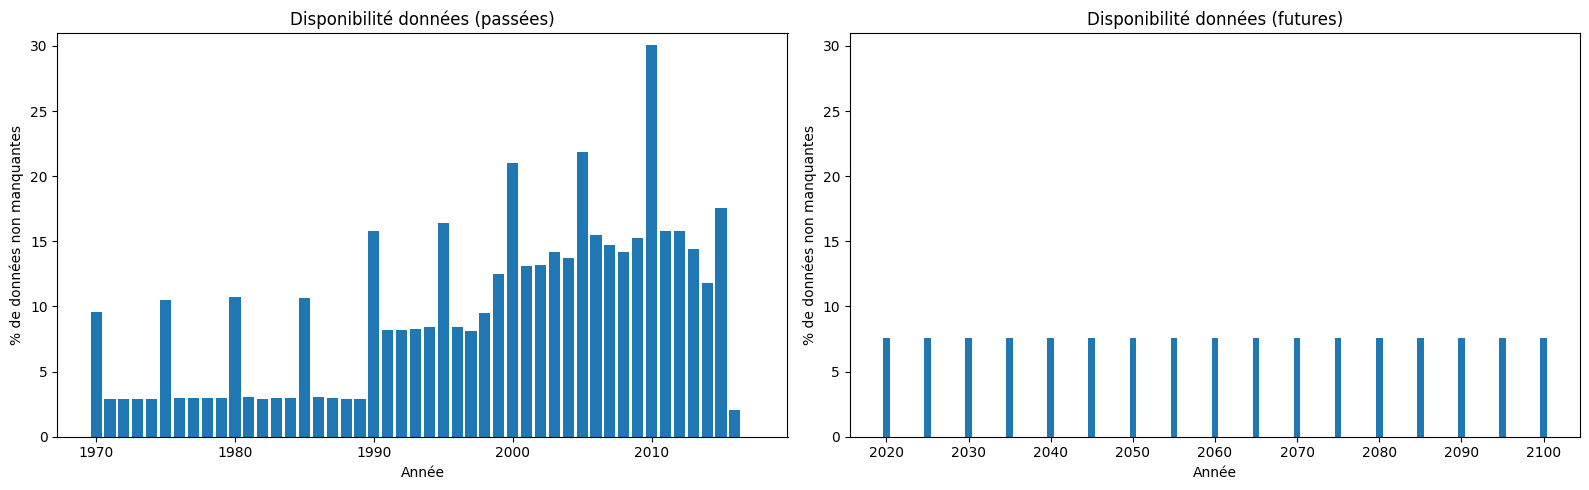

In [89]:
# Calculer la disponibilité des données
tmp_past_fill_rate = data_df[data_past_years].notna().mean() * 100
tmp_futur_fill_rate = data_df[data_futur_years].notna().mean() * 100

# Déterminer le tmp_ymax commun arrondi
tmp_ymax = np.ceil(max(tmp_past_fill_rate.max(), tmp_futur_fill_rate.max()))

plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.bar([int(year) for year in data_past_years], tmp_past_fill_rate)
plt.xlabel('Année')
plt.ylabel('% de données non manquantes')
plt.title('Disponibilité données (passées)')
plt.ylim(0, tmp_ymax)

plt.subplot(1, 2, 2)
plt.bar([int(year) for year in data_futur_years], tmp_futur_fill_rate)
plt.xlabel('Année')
plt.ylabel('% de données non manquantes')
plt.title('Disponibilité données (futures)')
plt.ylim(0, tmp_ymax)  

plt.tight_layout()
plt.show()

In [90]:
with track_dataframe_changes("data_df", "Suppréssion des années futures"):
    data_df = data_df.drop(columns=data_futur_years)

Suppréssion des années futures avant: (673920, 70)
Suppréssion des années futures après: (673920, 53)
  🗑️  Colonnes supprimées: 17
  ⏱️  Temps: 0.1180s
----------------------------------------


#### 4.3.4. Calcul de taux de couverture par année (tous indicateur et pays confondus)

In [91]:
data_current_years = [col for col in data_df.columns if col.isdigit()]
# Proportion (%) de valeurs renseignées pour chaque année, tous indicateurs et pays confondus
data_coverage_rate_by_year  = data_df[data_current_years].notna().mean().mul(100).round(2)

In [92]:
data_coverage_rate_by_year.head()

1970    9.56
1971    2.93
1972    2.87
1973    2.87
1974    2.87
dtype: float64

#### 4.3.5. Classement des indicateurs par complétude

##### 4.3.5.1. Calcul de taux moyen de couverture par indicateur (toutes années et tous pays)

In [93]:
# *** Etape 1 ***
# Proportion d'années avec données renseignées pour chaque ligne (pays, indicateur)
# ❗Attention: Cette colonne est déjà été crée dans la section "Utilité de la table EdStatsCountry-Series,
#   ceci est juste mise à jour de la colonne car entre temps on a supprimé les indicateurs ainsi que des années
with track_dataframe_changes("data_df", "Ajout d'une nouvelle colonne 'Year Coverage Rate'"):
    data_df["Year Coverage Rate"] = data_df[data_current_years].notna().mean(axis=1).round(2)

Ajout d'une nouvelle colonne 'Year Coverage Rate' avant: (673920, 53)
Ajout d'une nouvelle colonne 'Year Coverage Rate' après: (673920, 53)
  🔄 Aucun changement de dimension
  ⏱️  Temps: 0.2046s
----------------------------------------


In [94]:
# *** Etape 2 ***
# Calcul du taux moyen de couverture des données par indicateur (toutes années et tous pays)
# Affichage des 3 premiers indicateurs
coverage_by_indicator  = data_df.groupby("Indicator Code")["Year Coverage Rate"].mean().round(2)
coverage_by_indicator.head(3)

Indicator Code
BAR.NOED.1519.FE.ZS    0.13
BAR.NOED.1519.ZS       0.13
BAR.NOED.15UP.FE.ZS    0.13
Name: Year Coverage Rate, dtype: float64

#### 4.3.6. 🎓 Pré-sélection des 15 indicateurs les plus prometteurs
**Objectif** :
Indentifier les indicateurs les plus riches en données pour en séléctionner une quinzaine en tenant compte de la problématique métier.

##### 4.3.6.1. Transformation des données au format long

In [95]:
# Remettre la data_df au format long
data_long_df = pd.melt(
    data_df,
    id_vars = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    value_vars = data_current_years,
    var_name = "Year",
    value_name = "Value"  
)

In [96]:
data_long_df.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, both sexes (%)",UIS.NERA.2,1970,NaN
1,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, female (%)",UIS.NERA.2.F,1970,NaN
2,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, gender parity index ...",UIS.NERA.2.GPI,1970,NaN


##### 4.3.6.2. Calcul du nombre de pays par indicateur et année

In [97]:
# Grouper par indicateur et année, compter le nombre de pays avec une valeur non nulle
country_coverage_per_indicator = (
            data_long_df.dropna(subset=["Value"])
            .groupby(["Indicator Code","Indicator Name", "Year"])
            .agg( country_count = ("Country Code", "nunique") )
            .reset_index()
)
country_coverage_per_indicator.sort_values(by="country_count", ascending=False).head(3)

,Indicator Code,Indicator Name,Year,country_count
19893,SP.POP.TOTL,"Population, total",2010,215
19894,SP.POP.TOTL,"Population, total",2011,215
19882,SP.POP.TOTL,"Population, total",1999,215


##### 4.3.6.3. Classement des indicateurs par richesse

In [98]:
# Calcul de la moyenne du nombre de pays par indicateur (toutes années confondues)
indicator_richness = (
    country_coverage_per_indicator.groupby(["Indicator Code","Indicator Name"])
    .agg(country_mean = ("country_count", "mean")).round(2)
    .sort_values("country_mean", ascending=False)
    .reset_index()
)
indicator_richness.head(3)

,Indicator Code,Indicator Name,country_mean
0,SP.POP.TOTL,"Population, total",212.53
1,SP.POP.GROW,Population growth (annual %),212.40
2,UIS.THAGE.3.A.GPV,Official entrance age to upper secondary education (years),203.83


##### 4.3.6.4. Enrichissement des indicateurs avec les catégories(topics)

In [99]:
indicator_richness_with_topics = indicator_richness.merge(
                                series_df[["Series Code", "Topic"]],
                                left_on="Indicator Code",
                                right_on="Series Code",
                                how="left"
                                ).drop(columns="Series Code")
# 
indicator_richness_with_topics["high_priority"] = indicator_richness_with_topics["Topic"].isin(high_priority_topics)

In [ ]:
indicator_richness_with_topics.to_csv("../data/indicator_richness_with_topics.csv", sep=";")

##### 4.3.6.5. Sélection du meilleur indicateur par topic

In [101]:
# Étape 5 : Sélection du meilleur indicateur par topic

# Indicateurs riches dans une catégorie de priorité haute
# hp_indicator_richness_with_topics = indicator_richness_with_topics[indicator_richness_with_topics["high_priority"] == True].copy()

idx_max_country_mean = indicator_richness_with_topics.groupby("Topic")["country_mean"].idxmax()

max_indicators_per_topic = indicator_richness_with_topics.loc[idx_max_country_mean]

pd.set_option("display.max_colwidth", None)
max_indicators_per_topic[["country_mean", "Indicator Code", "Topic","Indicator Name"]]

,country_mean,Indicator Code,Topic,Indicator Name
241,166.00,PRJ.ATT.1519.NED.MA,Attainment,Wittgenstein Projection: Percentage of the population age 15-19 by highest level of educational attainment. No Education. Male
552,162.47,UIS.CEAGE.1,Background,Official entrance age to compulsory education (years)
553,156.51,NY.GNP.PCAP.CD,Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita,"GNI per capita, Atlas method (current US$)"
548,165.21,NY.GDP.MKTP.KD,Economic Policy & Debt: National accounts: US$ at constant 2010 prices: Aggregate indicators,GDP at market prices (constant 2005 US$)
239,172.36,NY.GDP.MKTP.CD,Economic Policy & Debt: National accounts: US$ at current prices: Aggregate indicators,GDP at market prices (current US$)
229,183.30,NY.GDP.MKTP.PP.KD,Economic Policy & Debt: Purchasing power parity,"GDP, PPP (constant 2011 international $)"
2137,8.77,HH.DHS.YRS.15UP.GIN.F,Education Equality,DHS: Gini coefficient of average years of schooling. Age 15+. Female
2484,6.00,SABER.GRVT.GOAL8.LVL7,Engaging the Private Sector (SABER),"SABER: (Engaging the Private Sector, Government funded) Policy Goal 8 Lever 7: Planning"
1036,79.41,UIS.XGDP.1.FSGOV,Expenditures,Government expenditure on primary education as % of GDP (%)
1,212.40,SP.POP.GROW,Health: Population: Dynamics,Population growth (annual %)


##### 4.3.6.6. Sélection finale de 15 indicateurs clés, équilibrant pertinence stratégique et richesse des données.
Sélection manuelle à partir des dataframes créés, organisée par sous-groupes stratégiques :
- Solvabilité & demande qualitative
- Capacité d'engagement & motivation
- Contexte & faisabilité

In [102]:
# Sélection finale de 15 indicateurs clés, équilibrant pertinence stratégique et richesse des données.

best_indicators = [
    # --- PILIERS ÉCONOMIQUES & DÉMOGRAPHIQUES ---

    # 1.[Meilleur de son Topic]: Mesure la taille économique réelle du marché (PPA), un indicateur clé de sa valeur. (country_mean: 183.3)
    'NY.GDP.MKTP.PP.KD',

    # 2.[Meilleur de son Topic] Estime le potentiel de croissance futur du marché, essentiel pour une vision à long terme. (country_mean: 212.4)
    'SP.POP.GROW',

    # 3.[Meilleur de son Topic] Indicateur de base pour la taille absolue du marché et son échelle potentielle. (country_mean: 212.53)
    'SP.POP.TOTL',

    # 4.[Meilleur de son Topic] Définit la taille du marché du travail que les étudiants s'apprêtent à intégrer. (country_mean: 185.7)
    'SL.TLF.TOTL.IN',	# Total Labor Force, Total, Index/Thousands 

    # 5.[Meilleur de son Topic] Chômage total (%). Indique un besoin de formation et de reconversion professionnelle (country_mean: 186.0)
    'SL.UEM.TOTL.ZS',

    # --- MESURE DU MARCHÉ CIBLE ---

    # 6.Population 15-64 ans (%). Évalue la part de la population en âge de travailler/étudier, un proxy clé du dynamisme démographique. (country_mean: 193.0)
    'SP.POP.1564.TO.ZS',

    # 7.Population 15-64 ans (valeur absolue). Quantifie la taille absolue de la population 15-64 ans, cruciale pour estimer le revenu potentiel. (country_mean: 192.26)
    'SP.POP.1564.TO',

    # 8.Population 15-24 ans (total). Le cœur de cible démographique exact pour Academy, avec une très bonne couverture (country_mean: 184.15)
    'SP.POP.1524.TO.UN',

    # 9.Population en âge d'être au lycée, mesure la taille théorique maximale du marché secondaire. (country_mean: 189.4)
    'SP.SEC.UTOT.IN',
    
    # 10. Taux de scolarisation au secondaire, mesure la taille réelle et active du marché "lycée". (country_mean: 126.23)
    'SE.SEC.ENRR',

    # --- SOLVABILITÉ & DEMANDE QUALITATIVE ---

    #11. PIB par habitant, PPA (constant). Mesure la plus fiable du pouvoir d'achat et de la solvabilité des clients (country_mean: 183.19)
    'NY.GDP.PCAP.PP.KD',
    
    # 12. Proxy pour la demande d'une éducation de qualité (étudiants cherchant des options à l'étranger). (country_mean: 196.19)
    'UIS.OE.56.40510',
    
    # 13. Mesure le niveau d'éducation supérieur des jeunes actifs (25-29 ans), un indicateur clé de la demande du marché. (country_mean: 166.0)
    'PRJ.ATT.2529.4.MF',

    # --- CONTEXTE & FAISABILITÉ ---
    
    # 14. Durée de la scolarité obligatoire, proxy de la valeur accordée à l'éducation dans le pays. (country_mean: 155.14)
    'SE.COM.DURS',

    # 15. Pénétration d'internet, prérequis technique indispensable pour l'accès à un service en ligne. (country_mean: 112.37)
    'IT.NET.USER.P2'
]   
display(Markdown(f"**{len(best_indicators)}** indicateur(s) sélectionné(s)"))


**15** indicateur(s) sélectionné(s)

In [103]:
check_invalid_best_indicator = set(best_indicators) - set(data_df["Indicator Code"].unique())
assert  len(check_invalid_best_indicator) == 0 , \
    f"""
    Erreur d'intégrité : 
    Indicateurs invalides: {check_invalid_best_indicator}    
    """
display(Markdown("🆗Validation d'intégrité réussie : \nTous les indicateurs selectionnés existent bien dans le jeux de données `data_df`"))

🆗Validation d'intégrité réussie : 
Tous les indicateurs selectionnés existent bien dans le jeux de données `data_df`

#### 4.3.7. Filtrage des indicateurs pertinents

Nous filtrons le DataFrame initial afin de ne conserver que les indicateurs que nous avons jugés pertinents dans nos analyses précédentes.
Cela permet de travailler uniquement sur les données utiles à notre exploration et modélisation.


In [104]:
# Filtrer data_df et ne garder que les indicateurs choisis (best_indicators)
with track_dataframe_changes("data_df", "Filtrage des indicateurs clés"):
    data_df = data_df[data_df["Indicator Code"].isin(best_indicators)]    

Filtrage des indicateurs clés avant: (673920, 53)
Filtrage des indicateurs clés après: (3240, 53)
  ✂️  Lignes supprimées: 670680
  ⏱️  Temps: 0.0593s
----------------------------------------


In [105]:
assert data_df["Indicator Code"].nunique() == len(best_indicators), "Le nombre d'indicateurs uniques dans data_df ne correspond pas à best_indicators."
print("Data validation 🆗 : Le nombre d'indicateurs est correct.")

Data validation 🆗 : Le nombre d'indicateurs est correct.


### 4.4. Filtre 3 : Élimination de la Redondance (Corrélation)
**Objectif** : Simplifier le modèle en supprimant les indicateurs qui apportent une information similaire (fortement corrélés), afin de ne garder que les variables les plus indépendantes et pertinentes.

#### 4.4.1. Sélection de la Période d'Analyse

Pour garantir la pertinence et l'actualité des données, notre analyse se concentrera sur la moyenne des **5 dernières années disponibles (2013-2017)**.

In [106]:
# Choix des années a analyser
data_recent_years = data_current_years[-5:]
display(f"Années sélectionnées : {data_recent_years}")

"Années sélectionnées : ['2013', '2014', '2015', '2016', '2017']"

#### 4.4.2. Préparation des Données pour l'Analyse
Pour calculer les corrélations, nous devons transformer notre jeu de données.

1.  **Format Long :** On transforme les colonnes d'années en une seule colonne `Year` et une colonne `Value`.
2.  **Agrégation :** On calcule la valeur moyenne de chaque indicateur pour chaque pays sur la période 2013-2017.

Le DataFrame résultant aura un pays par ligne et un indicateur par colonne.

In [107]:
# Convertir les années en format long
data_long_filtered_df = pd.melt(
    data_df,
    id_vars = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    value_vars = data_recent_years,
    var_name = "Year",
    value_name = "Value"     
)
#Afficher les premières lignes du DataFrame au format long
display(data_long_filtered_df.head(3))
display(data_long_filtered_df.shape)

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Afghanistan,AFG,Duration of compulsory education (years),SE.COM.DURS,2013,9.000000e+00
1,Afghanistan,AFG,"GDP per capita, PPP (constant 2011 international $)",NY.GDP.PCAP.PP.KD,2013,1.814156e+03
2,Afghanistan,AFG,"GDP, PPP (constant 2011 international $)",NY.GDP.MKTP.PP.KD,2013,5.756623e+10


(16200, 6)

In [108]:
# Agrégation par pays et indicateur en utilisant pivot_table
country_indicator_agg_df = (data_long_filtered_df
                .pivot_table(
                index = ['Country Name', 'Country Code'],
                columns = "Indicator Code",
                values = "Value",
                aggfunc = "mean", # Moyenne des années
    )
)

country_indicator_agg_df = country_indicator_agg_df.reset_index()
display(country_indicator_agg_df.head(3))
display(country_indicator_agg_df.shape)

Indicator Code,Country Name,Country Code,IT.NET.USER.P2,NY.GDP.MKTP.PP.KD,NY.GDP.PCAP.PP.KD,PRJ.ATT.2529.4.MF,SE.COM.DURS,SE.SEC.ENRR,SL.TLF.TOTL.IN,SL.UEM.TOTL.ZS,SP.POP.1524.TO.UN,SP.POP.1564.TO,SP.POP.1564.TO.ZS,SP.POP.GROW,SP.POP.TOTL,SP.SEC.UTOT.IN,UIS.OE.56.40510
0,Afghanistan,AFG,7.938932,5.878644e+10,1770.524956,NaN,9.0,55.996409,9814608.75,8.550,7.029547e+06,17480149.75,52.593206,3.032706,33220558.50,2202256.00,12003.0
1,Albania,ALB,61.729094,3.139216e+10,10881.029249,0.1,9.0,96.007716,1297436.50,16.350,5.693690e+05,1995335.00,69.157194,-0.210336,2885250.00,158522.25,24147.0
2,Algeria,DZA,33.286382,5.370031e+11,13595.714303,0.2,10.0,NaN,11860705.00,10.775,6.629419e+06,25937015.25,65.704069,1.945545,39482363.75,1866817.00,20695.0


(216, 17)

#### 4.4.3. Analyse de la Complétude des Indicateurs Sélectionnés
Après agrégation, nous vérifions le taux de remplissage de nos 15 indicateurs pré-sélectionnés.

**Constat**

- Taux de remplissage élevé (minimum 74%)
- Bonne qualité du dataset

**Décision**

Pas de suppression/imputation car :

- `.corr()` gère automatiquement les valeurs manquantes
- Conservation maximale des données

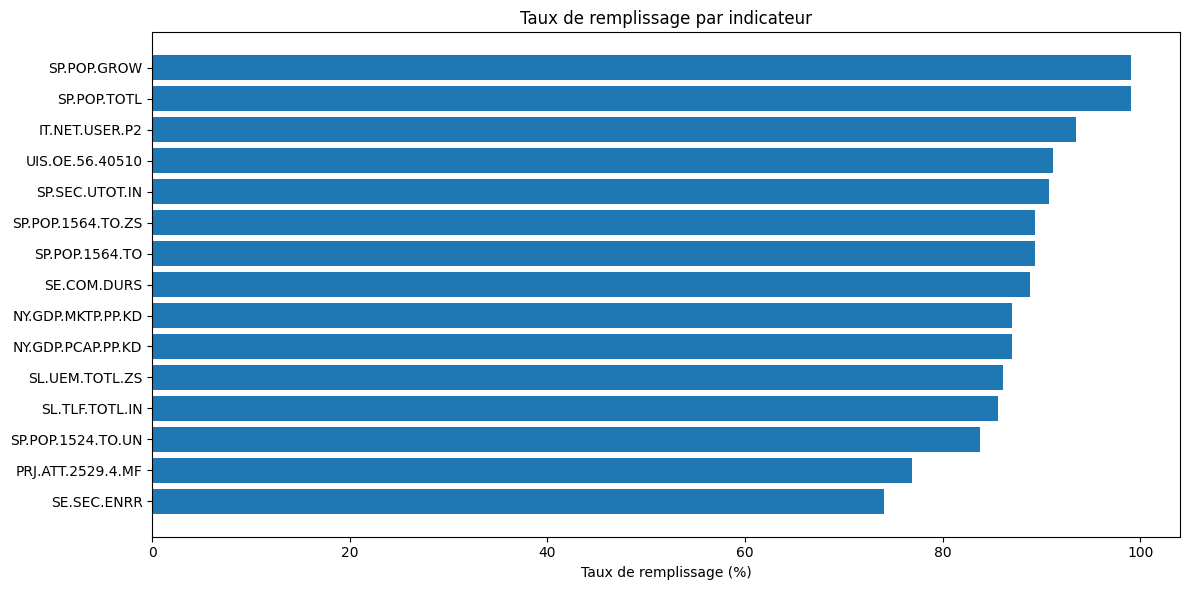

In [109]:
indicator_coverage = country_indicator_agg_df[best_indicators].notna().mean().mul(100)
indicator_coverage = indicator_coverage.sort_values()

plt.figure(figsize=(12,6))
plt.title("Taux de remplissage par indicateur")
plt.xlabel("Taux de remplissage (%)")
plt.barh(indicator_coverage.index, indicator_coverage.values)
plt.tight_layout()
plt.show()

#### 4.4.4. Matrice de Corrélation : Pearson vs. Spearman
Pour identifier les redondances, nous calculons deux types de corrélations avec un seuil de 0.70 pour définir une relation "forte".
- **Pearson** : Mesure les relations linéaires. Simple et direct.
- **Spearman** : Mesure les relations monotones (quand une variable augmente, l'autre aussi, mais pas forcément de façon linéaire). Plus robuste aux valeurs extrêmes.


In [110]:
correlation_matrix_pearson = country_indicator_agg_df[best_indicators].corr(method="pearson")
print(f"Taille de Pearson: {correlation_matrix_pearson.shape}")

correlation_matrix_spearman = country_indicator_agg_df[best_indicators].corr(method="spearman")
print(f"Taille de Spearman: {correlation_matrix_spearman.shape}")

Taille de Pearson: (15, 15)
Taille de Spearman: (15, 15)


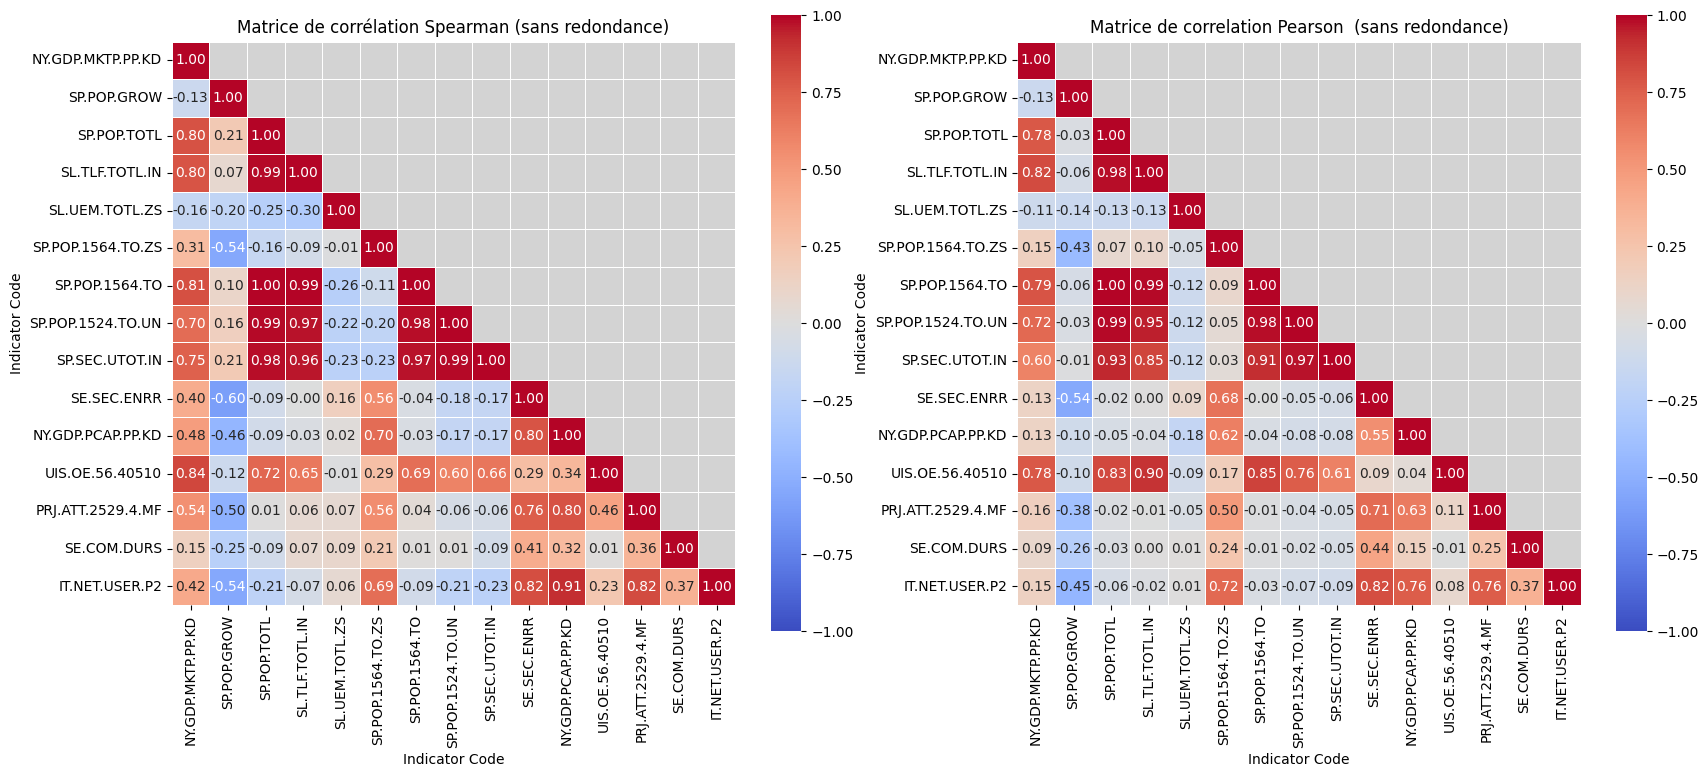

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(20,8))
du.plot_correlation_triangle(country_indicator_agg_df[best_indicators], method="spearman", ax=axes[0], title = "Matrice de corrélation Spearman (sans redondance)")
du.plot_correlation_triangle(country_indicator_agg_df[best_indicators],  method="pearson", ax=axes[1], title = "Matrice de correlation Pearson  (sans redondance)")
plt.tight_layout()
plt.show()

#### 4.4.5. Identification des Indicateurs Redondants

**Observation**
Il est logique d'obtenir plus de paires corrélées avec Spearman : ce coefficient met en évidence toutes les relations monotones, y compris celles qui échappent au coefficient de Pearson, limité aux seules relations linéaires. Cela montre que, dans notre dataset, certaines relations entre indicateurs sont fortement monotones mais non linéaires.

In [112]:
hc_indicators_spearman = du.get_highly_correlated_features(country_indicator_agg_df[best_indicators], method="spearman")
hc_indicators_pearson = du.get_highly_correlated_features(country_indicator_agg_df[best_indicators],  method = "pearson")
print(f"Nombre d'indicateurs à supprimer selon la méthode Spearman:  {len(hc_indicators_spearman)}")
print(f"Nombre d'indicateurs à supprimer selon la méthode Pearson:  {len(hc_indicators_pearson)}")

Nombre d'indicateurs à supprimer selon la méthode Spearman:  9
Nombre d'indicateurs à supprimer selon la méthode Pearson:  8


In [113]:
set(hc_indicators_spearman) -set(hc_indicators_pearson)

{'NY.GDP.PCAP.PP.KD'}

### 4.5. 🎯 Sélection Finale des Indicateurs : Démarche Stratégique

La liste finale `final_indicator_selection` a été établie en 3 étapes :

1.  **Analyse de Corrélation (Base Spearman)**
    *   La corrélation de **Spearman** est choisie comme base de décision car elle est plus robuste et détecte un plus grand nombre de relations pertinentes.
    *   Les indicateurs fortement corrélés (Spearman > 0.70) sont groupés.

2.  **Critère de Complétude**
    *   Au sein de chaque groupe corrélé, nous privilégions l'indicateur ayant le **meilleur taux de couverture** pour maximiser le nombre de pays dans notre analyse finale.

3.  **Pertinence Métier (Vision EdTech)**
    *   La décision finale est toujours guidée par la stratégie. Un indicateur crucial comme l'accès à Internet (`IT.NET.USER.P2`) est conservé même s'il est corrélé, car il est un prérequis pour notre business.

Cette démarche assure une sélection finale d'indicateurs à la fois **statistiquement indépendants, riches en données et stratégiquement alignés**.

**Liste finale des 6 indicateurs retenus :**
- Croissance démographique (`SP.POP.GROW`)
- Population totale (`SP.POP.TOTL`)
- Utilisateurs internet (`IT.NET.USER.P2`)
- Taux de chômage (`SL.UEM.TOTL.ZS`)
- Structure jeune/adulte (`SP.POP.1564.TO.ZS`)
- Durée de scolarisation (`SE.COM.DURS`)

#### 4.5.1. Diagnostic : Identification des Indicateurs Redondants

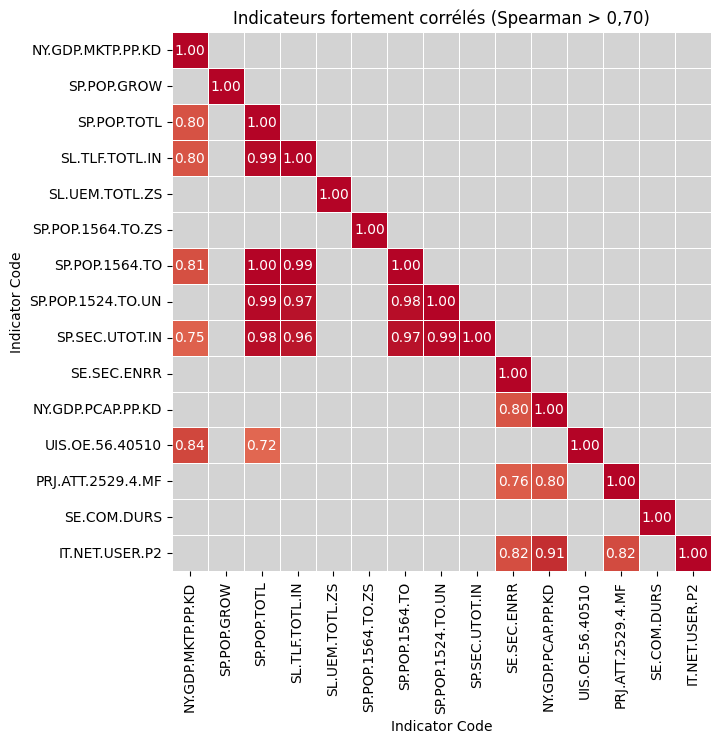

<Figure size 700x700 with 0 Axes>

In [114]:
du.plot_correlation_triangle(country_indicator_agg_df[best_indicators], 
                             method="spearman", 
                             title = "Indicateurs fortement corrélés (Spearman > 0,70)",
                             threshold=0.7, 
                             figsize=(7,7)                             
                            )

#### 4.5.2. Validation de la Sélection Finale
Ce second graphique sert de validation. En recalculant la matrice de corrélation uniquement sur nos 6 indicateurs finaux, nous confirmons qu'il n'existe plus aucune corrélation forte (supérieure à 0.70). Notre sélection est donc bien composée de variables statistiquement complémentaires, prêtes pour la construction de notre score de potentiel.

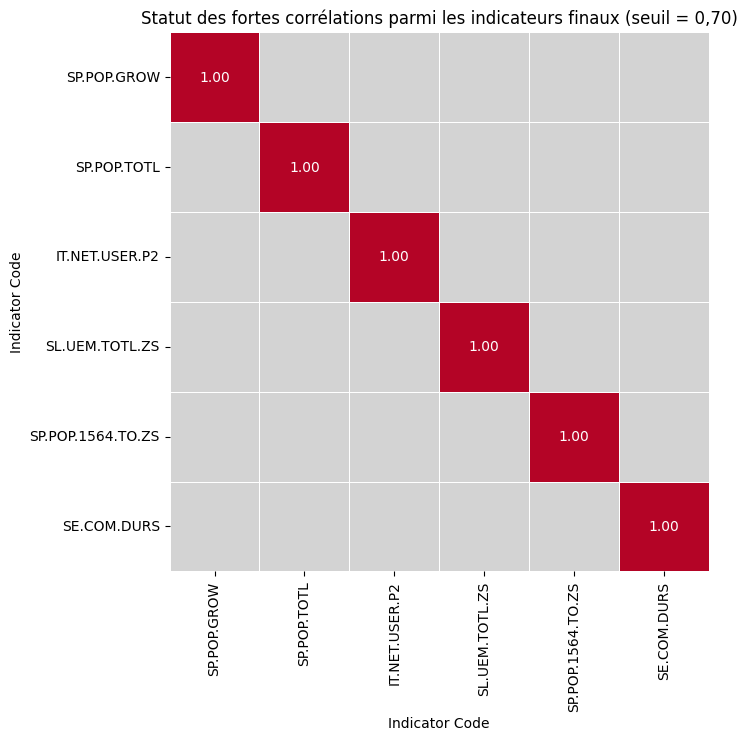

<Figure size 700x700 with 0 Axes>

In [115]:
final_indicator_selection = [
    'SP.POP.GROW', # Croissance démographique
    'SP.POP.TOTL', # Population totale
    'IT.NET.USER.P2', # Utilisateurs internet
    'SL.UEM.TOTL.ZS', # Taux de chômage
    'SP.POP.1564.TO.ZS', # Structure jeune/adulte
    'SE.COM.DURS' # Durée de scolarisation
]

# Ce graphique permet de vérifier l’absence de corrélations fortes (Spearman > 0,70)
# dans la sélection finale d'indicateurs, garantissant leur complémentarité.
du.plot_correlation_triangle(country_indicator_agg_df[final_indicator_selection], 
                             method="spearman", 
                             threshold=0.7, 
                             figsize=(7,7),
                             title= "Statut des fortes corrélations parmi les indicateurs finaux (seuil = 0,70)"
                             )

#### 4.5.3. 🧹 Application du Filtre Final

In [116]:
# Suppression des indicateurs fortement corrélés.
indicators_to_drop = list(set(best_indicators) - set(final_indicator_selection))
print(f"{len(indicators_to_drop)} indicateurs vont être supprimés")

print(f"Shape avant: {country_indicator_agg_df.shape}")
country_indicator_agg_df_final = country_indicator_agg_df.drop(columns=indicators_to_drop)
print(f"Shape après: {country_indicator_agg_df_final.shape}")

9 indicateurs vont être supprimés
Shape avant: (216, 17)
Shape après: (216, 8)


## 5. Méthodologie Quantitative et Classement des Pays
Cette section présente la méthode quantitative développée pour évaluer et classer le potentiel de chaque pays. Elle se base sur un score composite calculé à partir des indicateurs finaux.

### 5.1. Analyse Descriptive des Indicateurs Finaux
Avant de construire notre score, nous analysons la distribution de chaque indicateur final pour comprendre ses caractéristiques et interpréter sa signification pour notre projet.

In [117]:
example_indicator = "IT.NET.USER.P2"

dec_stats = country_indicator_agg_df_final[example_indicator].describe()
dec_stats

count    202.000000
mean      47.415015
std       28.730015
min        1.037713
25%       19.872111
50%       48.802729
75%       71.508144
max       97.786704
Name: IT.NET.USER.P2, dtype: float64

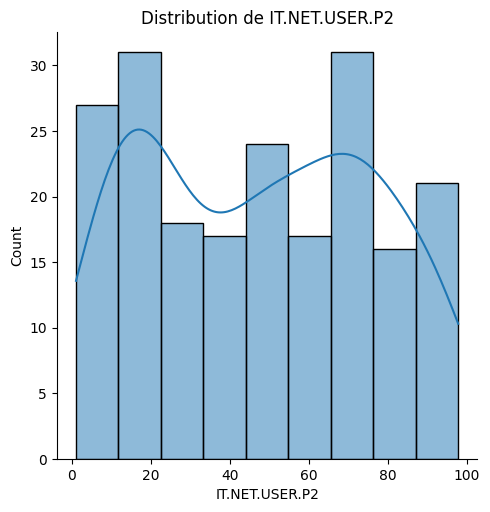

In [118]:
# Visualisation distribution
sns.displot(data = country_indicator_agg_df_final, x= example_indicator, kde=True)
plt.title(f"Distribution de {example_indicator}")
plt.show()

In [119]:
# Prépare un dictionnaire de descriptions pour les indicateurs sélectionnés
final_indicator_descriptions = (series_df[series_df["Series Code"]
                                 .isin(final_indicator_selection)]
                                 .set_index("Series Code")["Indicator Name"]
                                 .to_dict()
                                )

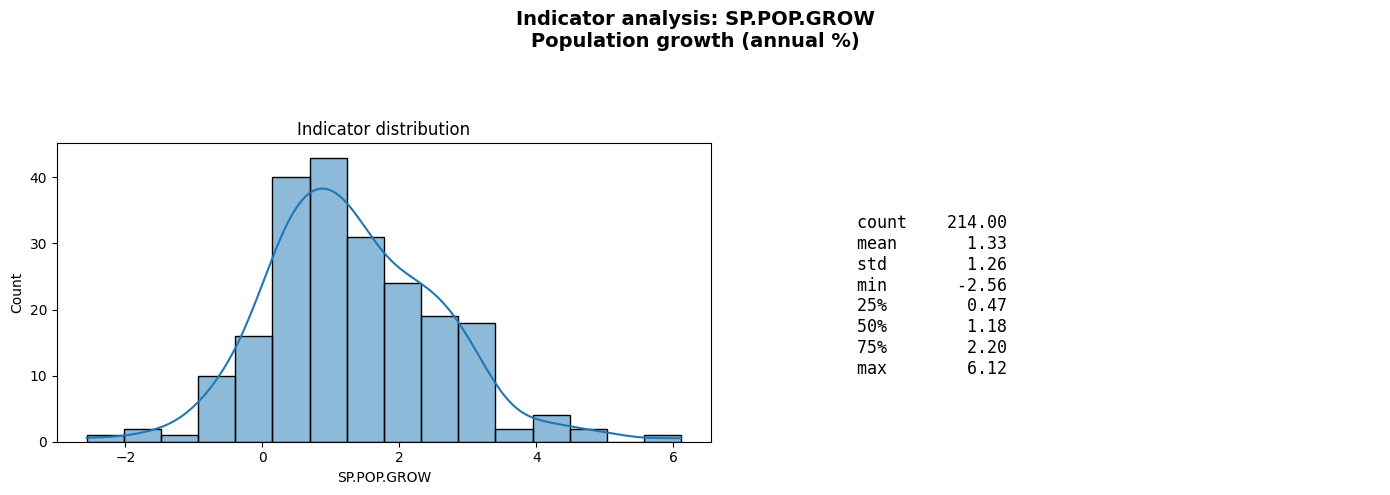

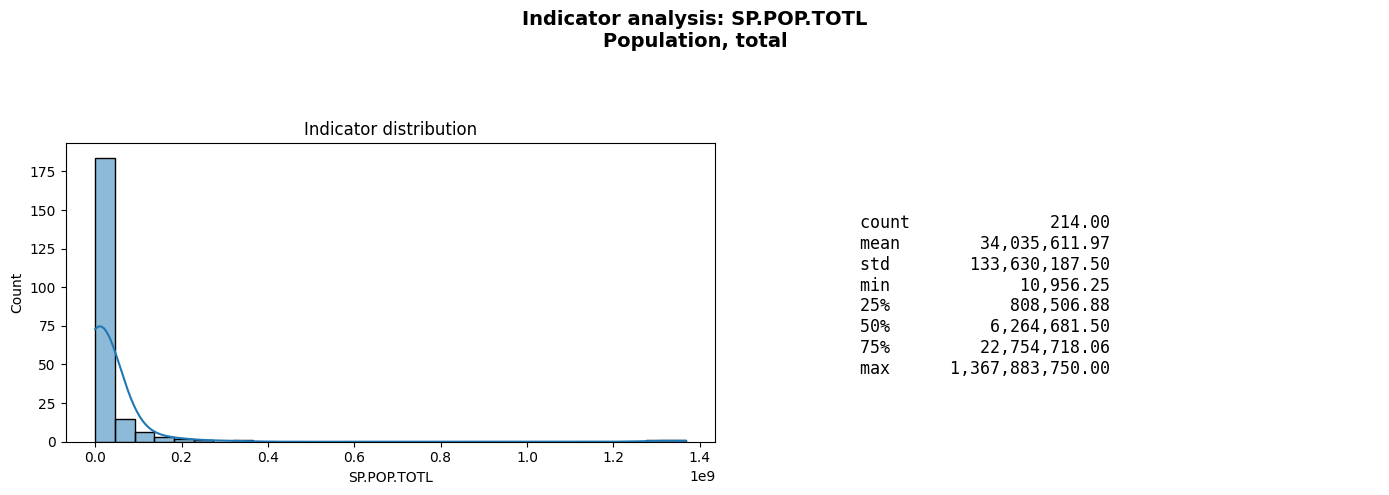

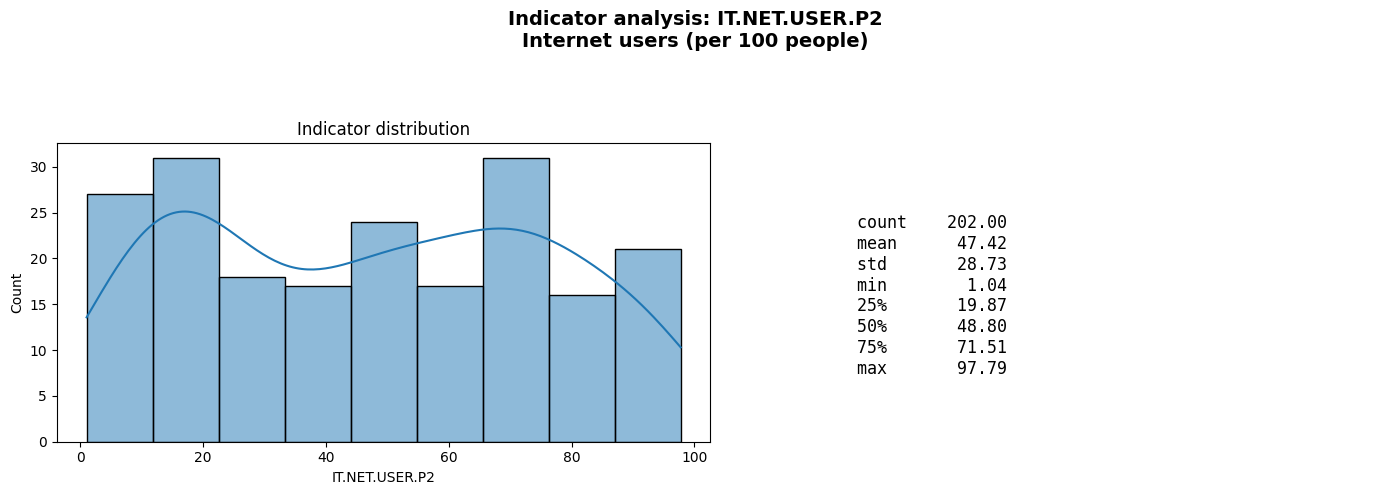

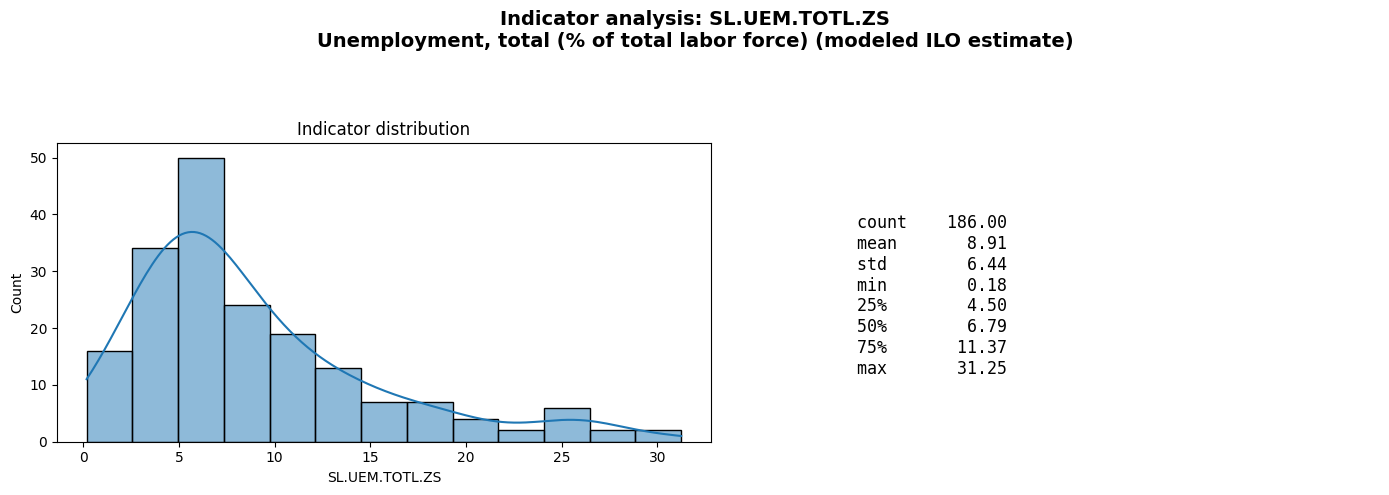

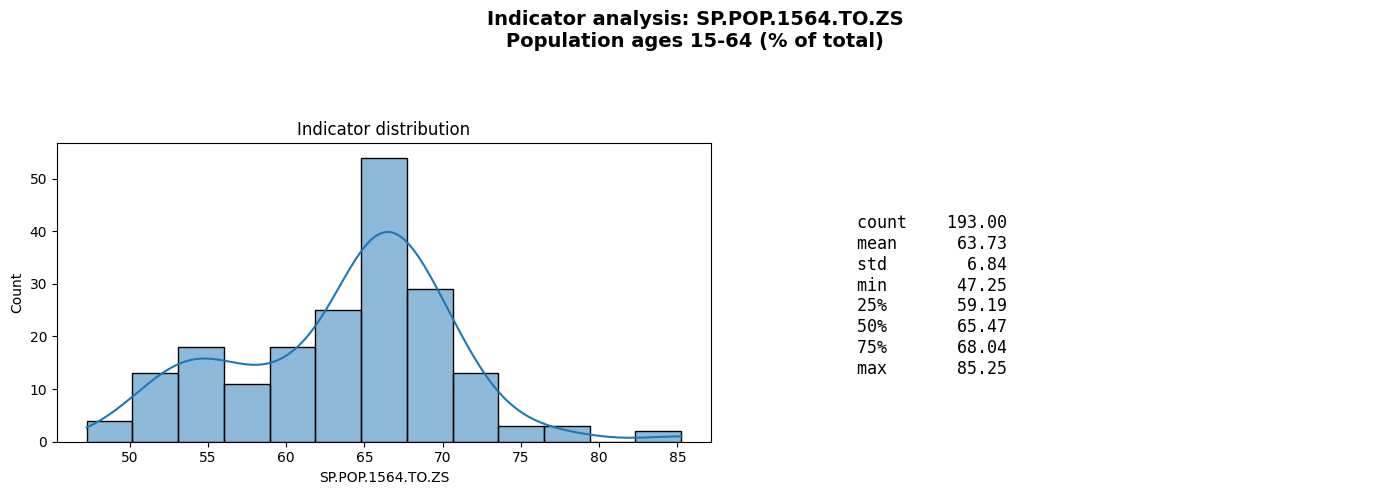

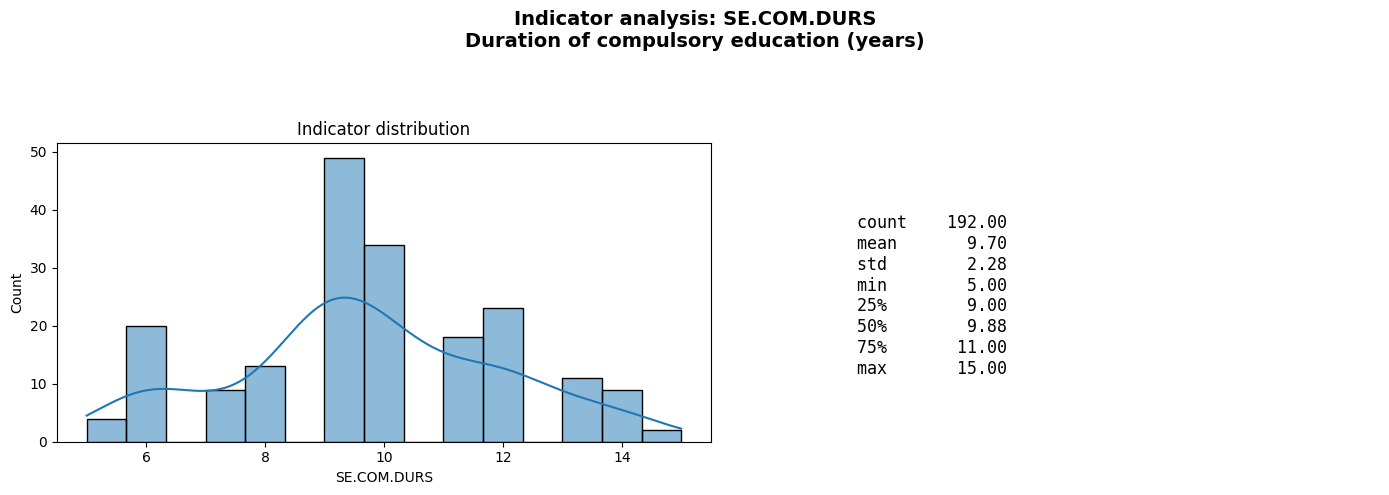

In [120]:
du.describe_and_displot(country_indicator_agg_df_final, final_indicator_selection, final_indicator_descriptions)       

### 5.2. Interprétation des distributions

| Indicateur | Distribution | Pertinence pour Academy |
| :--- | :--- | :--- |
| **SP.POP.GROW** | Asymétrique à droite | **Potentiel de croissance.** Un taux élevé suggère un marché jeune et dynamique, prometteur à long terme. |
| **SP.POP.TOTL**| Extrêmement asymétrique à droite | **Taille du marché.** Les pays très peuplés (quartile supérieur) offrent un volume de clients potentiels massif. |
| **IT.NET.USER.P2**| Bimodale ("fracture numérique") | **Prérequis technique.** Un taux élevé (&gt;70%) est indispensable. C'est un critère de viabilité immédiate. |
| **SL.UEM.TOTL.ZS**| Asymétrique à droite | **Indicateur de besoin.** Un chômage modéré (7-15%) peut stimuler la demande de formations pour améliorer l'employabilité. |
| **SP.POP.1564.TO.ZS**| Asymétrique à gauche | **Dynamique démographique.** Un faible % (forte proportion de jeunes) indique un grand réservoir de futurs étudiants. |
| **SE.COM.DURS** | Multimodale (pic à 9-10 ans) | **Culture de l'éducation.** Une durée longue (&gt;11 ans) signale une forte valorisation des études, donc un public réceptif. |

### 5.3. Construction du Score de Potentiel
Pour classer les pays, nous utilisons une méthode de **moyenne pondérée**. Chaque indicateur se voit attribuer un poids reflétant son importance stratégique pour Academy.

#### 5.3.1. : Préparation des Données
Les pays pour lesquels il manque des données sur l'un des indicateurs finaux sont exclus pour garantir un calcul de score fiable et comparable.

In [121]:
tmp_shape_before = country_indicator_agg_df_final.shape

# Nettoyage des données manquantes
country_indicator_clean  = country_indicator_agg_df_final.dropna(subset=final_indicator_selection)

du.report_shape_changes(tmp_shape_before, country_indicator_clean.shape)

Shape before: (216, 8)
Shape after:  (166, 8)
  ✂️  Rows removed: 50


#### 5.3.2. Normalisation
- Toutes les valeurs d'indicateurs sont normalisées sur une échelle de 0 à 1 (Min-Max Scaling).
- Cela permet de les comparer et de les agréger de manière équitable, quelle que soit leur unité d'origine (%, années, etc.).

In [122]:
tmp_shape_before= country_indicator_clean.shape

country_indicator_scaled = country_indicator_clean.copy()

#Normalisation
scaler = MinMaxScaler(clip=True) # True pour éviter les problèmes de précision de float pendant la normalisation
country_indicator_scaled[final_indicator_selection] = scaler.fit_transform(
    country_indicator_scaled[final_indicator_selection]
)

du.report_shape_changes(tmp_shape_before, country_indicator_scaled.shape)

display(Markdown("---"))
display(Markdown("**Aperçu après normalisation :**"))
country_indicator_scaled.head()

Shape before: (166, 8)
Shape after:  (166, 8)
  🔄 No dimension change


---

**Aperçu après normalisation :**

Indicator Code,Country Name,Country Code,IT.NET.USER.P2,SE.COM.DURS,SL.UEM.TOTL.ZS,SP.POP.1564.TO.ZS,SP.POP.GROW,SP.POP.TOTL
0,Afghanistan,AFG,0.047781,0.40,0.282683,0.087741,0.739185,0.024210
1,Albania,ALB,0.617856,0.40,0.547538,0.550522,0.310831,0.002032
2,Algeria,DZA,0.316417,0.50,0.358234,0.454045,0.595589,0.028788
5,Angola,AGO,0.081547,0.10,0.202037,0.030837,0.794727,0.019953
7,Argentina,ARG,0.659924,0.85,0.250424,0.402474,0.473160,0.031504


In [123]:
display(Markdown("**Min/Max après scaling :**"))
display(country_indicator_scaled[final_indicator_selection].describe())

**Min/Max après scaling :**

Indicator Code,SP.POP.GROW,SP.POP.TOTL,IT.NET.USER.P2,SL.UEM.TOTL.ZS,SP.POP.1564.TO.ZS,SE.COM.DURS
count,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,0.519192,0.031362,0.462240,0.296275,0.399631,0.449699
std,0.165888,0.110100,0.297481,0.213248,0.192171,0.227553
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.400966,0.002441,0.175221,0.154924,0.266448,0.300000
50%,0.502507,0.006895,0.464713,0.225806,0.446491,0.400000
75%,0.643087,0.022670,0.726222,0.378396,0.514600,0.600000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### 5.3.3. Inversion de l'indicateur SP.POP.1564.TO.ZS
L'indicateur `SP.POP.1564.TO.ZS` est inversé (`1 - valeur normalisée`).
*   **Logique :** Un score élevé sur cet indicateur signifie une faible proportion de jeunes (marché futur). Nous voulons l'inverse : un score élevé doit correspondre à un fort potentiel. L'inversion corrige cela.

In [124]:
country_indicator_scaled["SP.POP.1564.TO.ZS_inverted"] = 1 - country_indicator_scaled["SP.POP.1564.TO.ZS"]
final_indicator_selection.append("SP.POP.1564.TO.ZS_inverted")
assert np.allclose(
    country_indicator_scaled["SP.POP.1564.TO.ZS"] + 
    country_indicator_scaled["SP.POP.1564.TO.ZS_inverted"],
    1), "Erreur : La somme de la colonne et de son inverse n'est pas égale à 1. Vérifiez le scaling ou l'inversion."
print("Validation de Conversion 🆗")

Validation de Conversion 🆗


In [125]:
display(Markdown("**Min/Max après scaling et inversion:**"))
display(country_indicator_scaled[final_indicator_selection].describe())

**Min/Max après scaling et inversion:**

Indicator Code,SP.POP.GROW,SP.POP.TOTL,IT.NET.USER.P2,SL.UEM.TOTL.ZS,SP.POP.1564.TO.ZS,SE.COM.DURS,SP.POP.1564.TO.ZS_inverted
count,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,0.519192,0.031362,0.462240,0.296275,0.399631,0.449699,0.600369
std,0.165888,0.110100,0.297481,0.213248,0.192171,0.227553,0.192171
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.400966,0.002441,0.175221,0.154924,0.266448,0.300000,0.485400
50%,0.502507,0.006895,0.464713,0.225806,0.446491,0.400000,0.553509
75%,0.643087,0.022670,0.726222,0.378396,0.514600,0.600000,0.733552
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### 5.3.4. Pondération et Score Final
Un score final est calculé pour chaque pays en appliquant les poids stratégiques suivants :

| Indicateur | Poids | Justification Stratégique |
|:---|:---:|:---|
| 🌐 **Accès Internet (`IT.NET.USER.P2`)** | **35%** | **Critère éliminatoire.** Sans accès, notre service est inutile. C'est le pilier technique. |
| 👥 **Population Totale (`SP.POP.TOTL`)** | **25%** | **Taille du marché.** Impact direct sur le revenu potentiel total (Total Addressable Market). |
| 🌱 **Structure Démographique (`SP.POP.1564.TO.ZS_inverted`)** | **15%** | **Potentiel futur.** Mesure le réservoir de futurs étudiants. Clé pour la croissance à long terme. |
| 📈 **Croissance Démographique (`SP.POP.GROW`)** | **15%** | **Dynamisme du marché.** Un marché en croissance est plus facile à pénétrer. |
| 🎓 **Durée de Scolarisation (`SE.COM.DURS`)** | **10%** | **Culture de l'éducation.** Un proxy de la valeur accordée à l'éducation par la société. |
| 💼 **Taux de Chômage (`SL.UEM.TOTL.ZS`)** | **(Exclu)** | **Ambigu.** Peut indiquer un risque (instabilité) ou une opportunité (besoin de formation). Exclu pour ne pas fausser la clarté du score. |

*Un filtre préliminaire est appliqué : seuls les pays avec plus de **35%** de pénétration Internet sont considérés pour le classement final.*

In [126]:
# FILTRE ÉLIMINATOIRE SUR L'ACCÈS INTERNET
# Comme l'accès internet est indispensable pour notre formation definir un poids plus elevé ne serait pas suffisant, 
# par conséquant j'ai décidé d'appliquer un fitre en ce basant sur cet indicateur.


# Seuil minimum d'accès Internet (%)
INTERNET_THRESHOLD = 35.0

internet_viable_idx = country_indicator_clean[country_indicator_clean["IT.NET.USER.P2"] >= INTERNET_THRESHOLD].index
internet_viable = country_indicator_scaled.loc[internet_viable_idx].copy()

print(f"Pays viables (accès Internet > {INTERNET_THRESHOLD}%) : {len(internet_viable)}")


# DÉFINITION DES POIDS STRATÉGIQUES POUR LE CALCUL DU SCORE DE POTENTIEL
# ---------------------------------------------------------------------
# Remarque : L'indicateur de chômage (SL.UEM.TOTL.ZS) n'est pas inclus.
# Il est ambigu : il peut signifier un problème (risque) ou une opportunité (besoin de formation).
# Pour rester simple et éviter d'avoir un score brouillé, on ne le prend pas en compte.


weights = {
    # 1. Accès à Internet : La viabilité technique du marché. Indispensable.
    'IT.NET.USER.P2': 0.35,

    # 2. Population totale : La taille actuelle du marché. Un grand pays est plus attractif.
    'SP.POP.TOTL': 0.25,

    # 3. Part de jeunes (critère inversé) : plus il y a de jeunes à venir, mieux c'est pour le futur.
    'SP.POP.1564.TO.ZS_inverted': 0.15,

    # 4. Croissance démographique : un marché qui grossit rapidement peut être intéressant.
    'SP.POP.GROW': 0.15,

    # 5. Durée moyenne de scolarisation : plus les gens étudient longtemps, plus ils valorisent la formation.
    'SE.COM.DURS': 0.10
}

# Vérifie que la somme des poids = 1
assert abs(sum(weights.values()) - 1.0) < 1e-8, "La somme des poids doit être égale à 1."

# Calcul du score pondéré
internet_viable["country_score"] = 0.0
for indicator, weight in weights.items():
    if indicator in internet_viable.columns:
        internet_viable["country_score"] += internet_viable[indicator] * weight

Pays viables (accès Internet > 35.0%) : 102


## 6. 🏆 Liste des pays recommandés

In [127]:
# Tri final et affichage du TOP 5
top_countries = internet_viable.sort_values("country_score", ascending=False)[["Country Name", "country_score"]].reset_index(drop=True)

display(Markdown("**Liste des Top 5 Pays à fort potentiel**"))
display(top_countries.head(5))  # Affichage stylé en notebook

**Liste des Top 5 Pays à fort potentiel**

Indicator Code,Country Name,country_score
0,Luxembourg,0.576223
1,China,0.573302
2,United Kingdom,0.553302
3,Iceland,0.551356
4,Norway,0.548647
